#### Importing Libraries

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Data Fetching

In [2]:
df=pd.read_excel("bioactivity_dataset.xlsx", sheet_name="Sheet1")
df.head(3)

,molecule_chembl_id,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class
0,CHEMBL323869,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4,6,8.6,active
1,CHEMBL327146,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4,6,9.0,active
2,CHEMBL116620,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,415.449,3.5662,4,4,9.0,active


#### Data Cleaning

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6629 entries, 0 to 6628
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   molecule_chembl_id  6629 non-null   object 
 1   canonical_smiles    6628 non-null   object 
 2   MW                  6629 non-null   float64
 3   LogP                6629 non-null   float64
 4   NumHDonors          6629 non-null   int64  
 5   NumHAcceptors       6629 non-null   int64  
 6   pIC50               6629 non-null   float64
 7   bioactivity_class   6629 non-null   object 
dtypes: float64(3), int64(2), object(3)
memory usage: 414.4+ KB


In [4]:
df.describe(include='all')

c:\BioActivity\.venv\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,molecule_chembl_id,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class
count,6629,6628,6629.000000,6629.000000,6629.000000,6629.000000,6629.00,6629
unique,5473,5472,NaN,NaN,NaN,NaN,NaN,2
top,CHEMBL98,O=C(CCCCCCC(=O)Nc1ccccc1)NO,NaN,NaN,NaN,NaN,NaN,active
freq,320,320,NaN,NaN,NaN,NaN,NaN,5383
mean,NaN,NaN,419.852171,3.584722,2.881883,5.550913,inf,NaN
std,NaN,NaN,120.481158,1.437887,1.132482,2.430323,NaN,NaN
min,NaN,NaN,75.067000,-14.260700,0.000000,0.000000,2.39,NaN
25%,NaN,NaN,341.411000,2.554200,2.000000,4.000000,6.17,NaN
50%,NaN,NaN,401.511000,3.478400,3.000000,5.000000,6.88,NaN
75%,NaN,NaN,481.560000,4.450500,3.000000,7.000000,7.60,NaN


In [5]:
df['pIC50']=df['pIC50'].replace(['inf', np.inf], np.nan)
df.describe(include='all')

,molecule_chembl_id,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class
count,6629,6628,6629.000000,6629.000000,6629.000000,6629.000000,6627.000000,6629
unique,5473,5472,NaN,NaN,NaN,NaN,NaN,2
top,CHEMBL98,O=C(CCCCCCC(=O)Nc1ccccc1)NO,NaN,NaN,NaN,NaN,NaN,active
freq,320,320,NaN,NaN,NaN,NaN,NaN,5383
mean,NaN,NaN,419.852171,3.584722,2.881883,5.550913,6.752300,NaN
std,NaN,NaN,120.481158,1.437887,1.132482,2.430323,1.286299,NaN
min,NaN,NaN,75.067000,-14.260700,0.000000,0.000000,2.390000,NaN
25%,NaN,NaN,341.411000,2.554200,2.000000,4.000000,6.170000,NaN
50%,NaN,NaN,401.511000,3.478400,3.000000,5.000000,6.880000,NaN
75%,NaN,NaN,481.560000,4.450500,3.000000,7.000000,7.600000,NaN


In [6]:
df.isnull().sum()

molecule_chembl_id    0
canonical_smiles      1
MW                    0
LogP                  0
NumHDonors            0
NumHAcceptors         0
pIC50                 2
bioactivity_class     0
dtype: int64

In [7]:
df.dropna(inplace=True)
df.isnull().sum()

molecule_chembl_id    0
canonical_smiles      0
MW                    0
LogP                  0
NumHDonors            0
NumHAcceptors         0
pIC50                 0
bioactivity_class     0
dtype: int64

In [13]:
import pandas as pd
df_ = pd.DataFrame({'A': [2, 1, 0, 2, 6], 'B': [4, 3, 5, 4, 9]})
print(df_.duplicated())
# Output:
# 0    False
# 1    False
# 2     True
# dtype: bool

print(df_.duplicated().sum())  # Output: 1

0    False
1    False
2    False
3     True
4    False
dtype: bool
1


In [14]:
df_.head(5)

,A,B
0,2,4
1,1,3
2,0,5
3,2,4
4,6,9


In [8]:
df.duplicated().sum()

np.int64(285)

In [9]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop(['molecule_chembl_id'], axis=1, inplace=True)

In [11]:
df.to_excel("bioactivity_dataset_cleaned.xlsx", index=False)

#### Data Analysis

In [12]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

In [13]:
print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['MW', 'LogP', 'NumHDonors', 'NumHAcceptors', 'pIC50']
Categorical Columns: ['canonical_smiles', 'bioactivity_class']


In [14]:
df[categorical_cols].nunique()

canonical_smiles     5470
bioactivity_class       2
dtype: int64

In [15]:
from rdkit import Chem

invalid_smiles_mask = df['canonical_smiles'].apply(lambda x: Chem.MolFromSmiles(x) is None)
invalid_smiles = df[invalid_smiles_mask]

print(f"Number of invalid SMILES: {invalid_smiles_mask.sum()}")

Number of invalid SMILES: 0


Text(0.5, 1.0, 'Distribution of Bioactivity Classes')

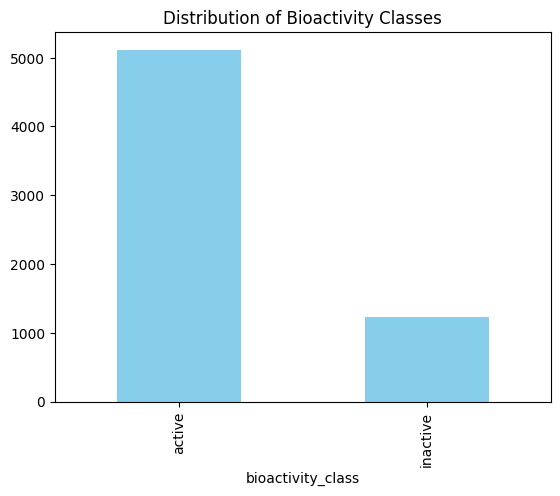

In [16]:
df['bioactivity_class'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution of Bioactivity Classes')

In [17]:
df.describe(include='all')

,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class
count,6341,6341.000000,6341.000000,6341.000000,6341.000000,6341.000000,6341
unique,5470,NaN,NaN,NaN,NaN,NaN,2
top,O=C(CCCCCCC(=O)Nc1ccccc1)NO,NaN,NaN,NaN,NaN,NaN,active
freq,247,NaN,NaN,NaN,NaN,NaN,5118
mean,NaN,423.154674,3.607172,2.886296,5.617726,6.739003,NaN
std,NaN,120.324203,1.446058,1.146729,2.446312,1.297159,NaN
min,NaN,75.067000,-14.260700,0.000000,0.000000,2.390000,NaN
25%,NaN,345.786000,2.579300,2.000000,4.000000,6.150000,NaN
50%,NaN,405.477000,3.520340,3.000000,5.000000,6.860000,NaN
75%,NaN,484.603000,4.485520,3.000000,7.000000,7.600000,NaN


#### Feature Transformation

In [4]:
df_cleaned=pd.read_excel("bioactivity_dataset_cleaned.xlsx", sheet_name="Sheet1")
df_cleaned.head(3)

,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4,6,8.6,active
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4,6,9.0,active
2,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,415.449,3.5662,4,4,9.0,active


In [4]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['bioactivity_class'], drop_first=True)
df_cleaned.head(5)

,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class_inactive
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4,6,8.6,False
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4,6,9.0,False
2,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,415.449,3.5662,4,4,9.0,False
3,O=C(CCCCCCC(=O)Nc1ccccc1)NO,264.325,2.4711,3,3,6.7,False
4,O=C(CCCCCC/C(=N\O)c1ccc(-c2ccccc2)cc1)NO,340.423,4.3779,3,4,8.4,False


Text(0.5, 1.0, 'Distribution of Bioactivity Classes')

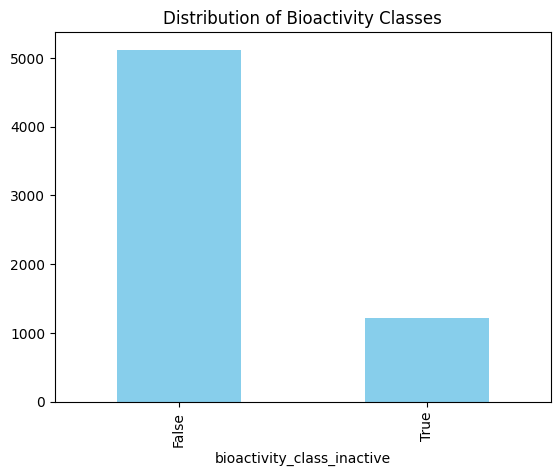

In [5]:
df_cleaned['bioactivity_class_inactive'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution of Bioactivity Classes')

In [6]:
features_df = df_cleaned.drop(['bioactivity_class_inactive', 'pIC50'], axis=1)
target_df = df_cleaned['bioactivity_class_inactive']

In [7]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6341 entries, 0 to 6340
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   canonical_smiles            6341 non-null   object 
 1   MW                          6341 non-null   float64
 2   LogP                        6341 non-null   float64
 3   NumHDonors                  6341 non-null   int64  
 4   NumHAcceptors               6341 non-null   int64  
 5   pIC50                       6341 non-null   float64
 6   bioactivity_class_inactive  6341 non-null   bool   
dtypes: bool(1), float64(3), int64(2), object(1)
memory usage: 303.6+ KB


In [ ]:
# smiles= features_df['canonical_smiles']

In [8]:
numerical_cols= features_df.select_dtypes(include=[np.number]).columns.tolist()

In [9]:
numerical_cols

['MW', 'LogP', 'NumHDonors', 'NumHAcceptors']

Text(0.5, 1.0, 'Boxplots of Numerical Features')

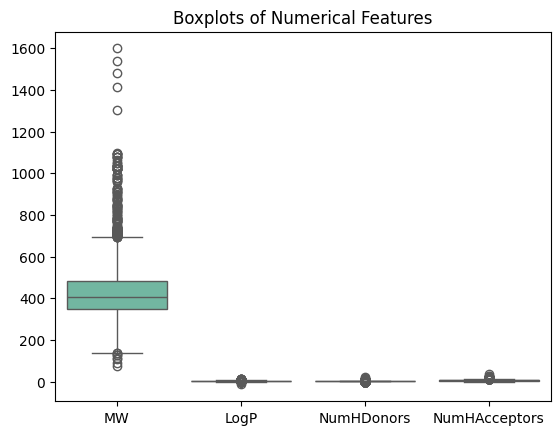

In [10]:
sns.boxplot(data=features_df[numerical_cols], orient='v', palette='Set2')
plt.title('Boxplots of Numerical Features')

In [12]:
# # Calculate Q1 (25th percentile) and Q3 (75th percentile) for each column
# Q1 = features_df[numerical_cols].quantile(0.25)
# Q3 = features_df[numerical_cols].quantile(0.75)

# # Calculate the IQR for each column
# IQR = Q3 - Q1

# # Define the lower and upper bounds for outliers
# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR

# # Identify rows where the data points are outside the bounds
# outliers = ((features_df[numerical_cols] < lower_bound) | (features_df[numerical_cols] > upper_bound)).any(axis=1)

# # Remove outliers from the dataset
# features_df = features_df[~outliers]

# # Check the result
# print(f"Original dataset size: {features_df.shape[0]}")
# print(f"Dataset size after removing outliers: {features_df.shape[0]}")

#features_df=features_df.copy()


Text(0.5, 1.0, 'Boxplots of Numerical Features')

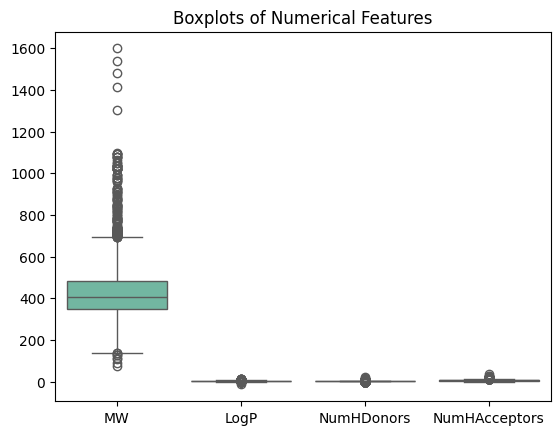

In [11]:

sns.boxplot(data=features_df[numerical_cols], orient='v', palette='Set2')
plt.title('Boxplots of Numerical Features')

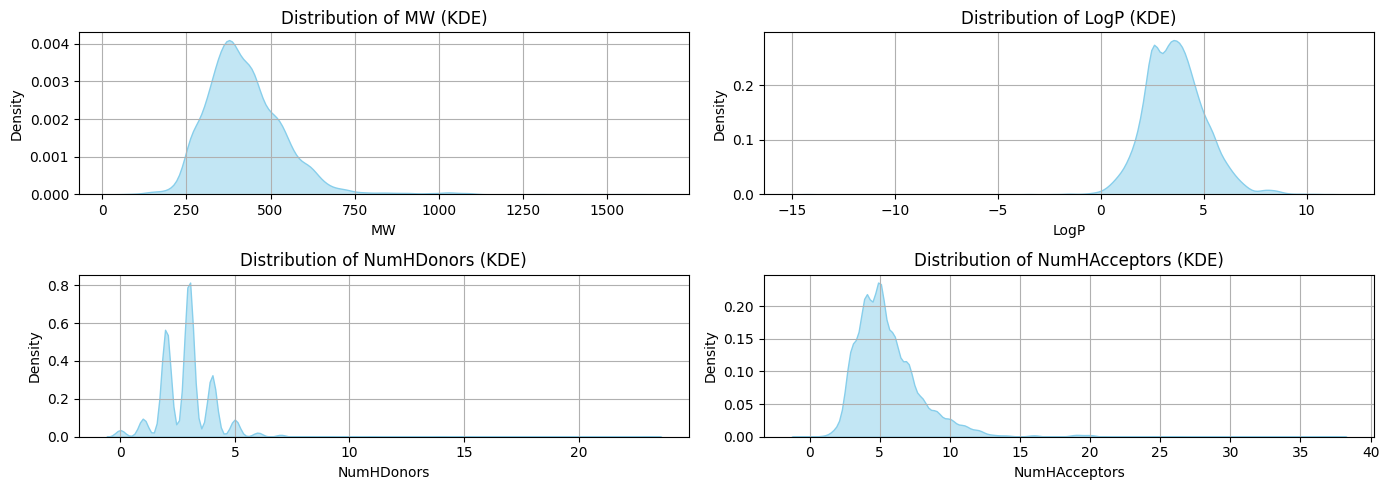

In [12]:

# If there are more than one plot, arrange two plots per row
fig, axes = plt.subplots(nrows=(len(numerical_cols) + 1) // 2, ncols=2, figsize=(14, 2.5 * ((len(numerical_cols) + 1) // 2)))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].set_title(f'Distribution of {col} (KDE)')
    sns.kdeplot(features_df[col], ax=axes[i], color='skyblue', fill=True, alpha=0.5)
    axes[i].set_ylabel('Density')
    axes[i].grid()
    axes[i].set_xlabel(col)
plt.tight_layout()
plt.show()

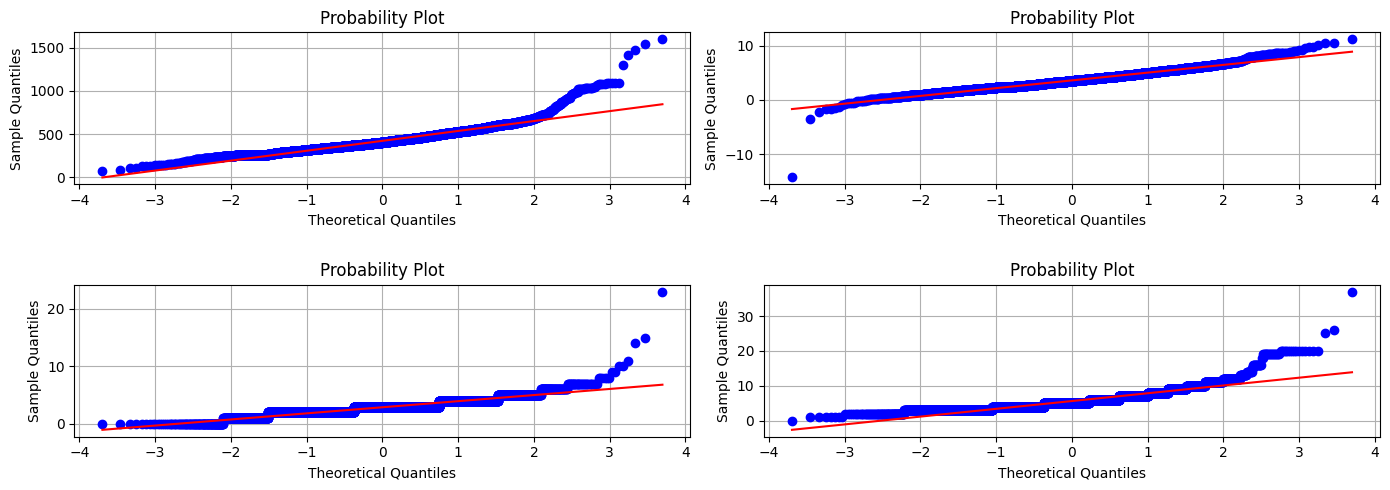

In [13]:
import scipy.stats as stats

fig, axes = plt.subplots(nrows=(len(numerical_cols) + 1) // 2, ncols=2, figsize=(14, 2.5 * ((len(numerical_cols) + 1) // 2)))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    axes[i].set_title(f'Q-Q Plot of {col}')
    stats.probplot(features_df[col], dist="norm", plot=axes[i])
    axes[i].set_xlabel('Theoretical Quantiles')
    # Add gap between rows by increasing vertical space between subplots
    plt.tight_layout(h_pad=2.5)
    axes[i].set_ylabel('Sample Quantiles')
    axes[i].grid()

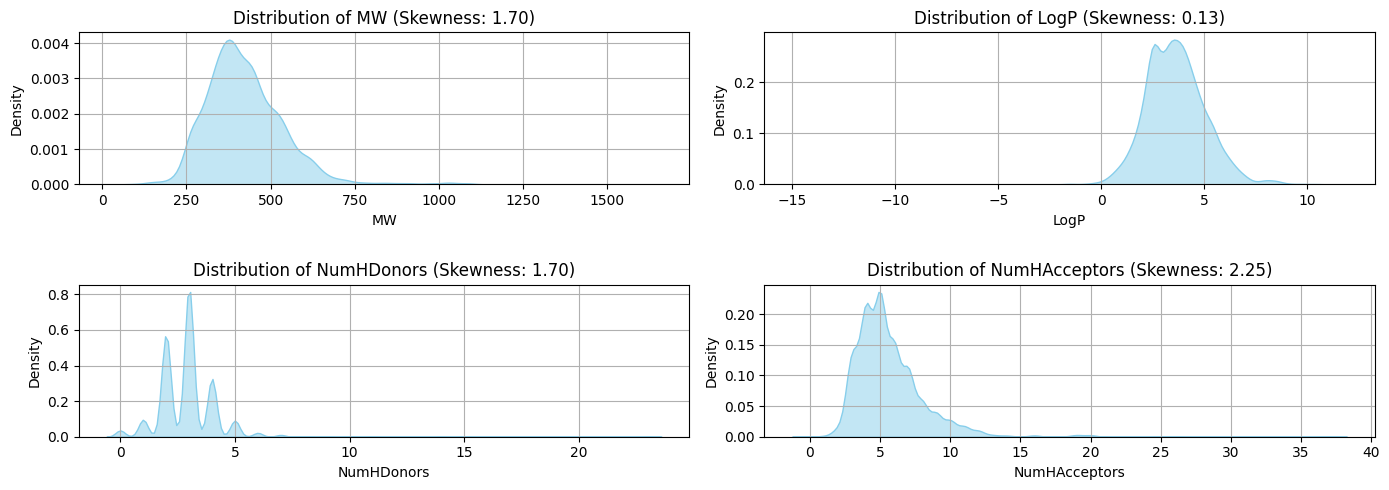

In [18]:
fig, axes = plt.subplots(nrows=(len(numerical_cols) + 1) // 2, ncols=2, figsize=(14, 2.5 * ((len(numerical_cols) + 1) // 2)))
axes = axes.flatten()
for i, column in enumerate(numerical_cols):
    skewness = stats.skew(features_df[column])  # Calculate skewness
    
    # Plot histogram for visual inspection
    sns.kdeplot(features_df[column], ax=axes[i], color='skyblue', fill=True, alpha=0.5)
    axes[i].set_title(f'Distribution of {column} (Skewness: {skewness:.2f})')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Density')
    axes[i].grid()
    plt.tight_layout(h_pad=2.5)
plt.show()

In [19]:
for column in numerical_cols:
    stat, p_value = stats.normaltest(features_df[column])
    print(f'Normality Test for {column}: Stat={stat:.3f}, p-value={p_value:.3f}')
    if p_value < 0.05:
        print(f'{column} is significantly not normal (p < 0.05)')
    else:
        print(f'{column} is approximately normal (p >= 0.05)')

Normality Test for MW: Stat=2536.683, p-value=0.000
MW is significantly not normal (p < 0.05)
Normality Test for LogP: Stat=663.415, p-value=0.000
LogP is significantly not normal (p < 0.05)
Normality Test for NumHDonors: Stat=3107.232, p-value=0.000
NumHDonors is significantly not normal (p < 0.05)
Normality Test for NumHAcceptors: Stat=3327.011, p-value=0.000
NumHAcceptors is significantly not normal (p < 0.05)


In [20]:
import scipy

features_df['MW']=np.log(features_df['MW']+1)
features_df['NumHDonors']=np.log(features_df['NumHDonors']+1)
features_df['NumHAcceptors']=np.log(features_df['NumHAcceptors']+1)

In [21]:
for column in numerical_cols:
    stat, p_value = stats.normaltest(features_df[column])
    print(f'Normality Test for {column}: Stat={stat:.3f}, p-value={p_value:.3f}')
    if p_value < 0.05:
        print(f'{column} is significantly not normal (p < 0.05)')
    else:
        print(f'{column} is approximately normal (p >= 0.05)')

Normality Test for MW: Stat=240.686, p-value=0.000
MW is significantly not normal (p < 0.05)
Normality Test for LogP: Stat=663.415, p-value=0.000
LogP is significantly not normal (p < 0.05)
Normality Test for NumHDonors: Stat=1549.697, p-value=0.000
NumHDonors is significantly not normal (p < 0.05)
Normality Test for NumHAcceptors: Stat=319.645, p-value=0.000
NumHAcceptors is significantly not normal (p < 0.05)


In [22]:
for col in numerical_cols:
    features_df[col] = (features_df[col] - features_df[col].mean()) / features_df[col].std()
features_df[numerical_cols].head(3)

,MW,LogP,NumHDonors,NumHAcceptors
0,0.483099,0.219236,0.943334,0.344859
1,0.648027,0.570605,0.943334,0.344859
2,0.067137,-0.028334,0.943334,-0.692281


In [23]:
for col in numerical_cols:
    skewness = stats.skew(features_df[col])  # Calculate skewness
    print(f'Skewness of {col}: {skewness:.2f}')
    
    if abs(skewness) > 0.5:
        print(f'{col} is significantly skewed (|Skewness| > 0.5)')
    else:
        print(f'{col} is approximately symmetric (|Skewness| <= 0.5)')

Skewness of MW: 0.03
MW is approximately symmetric (|Skewness| <= 0.5)
Skewness of LogP: 0.13
LogP is approximately symmetric (|Skewness| <= 0.5)
Skewness of NumHDonors: -1.15
NumHDonors is significantly skewed (|Skewness| > 0.5)
Skewness of NumHAcceptors: 0.47
NumHAcceptors is approximately symmetric (|Skewness| <= 0.5)


In [24]:
for column in numerical_cols:
    stat, p_value = stats.normaltest(features_df[column])
    print(f'Normality Test for {column}: Stat={stat:.3f}, p-value={p_value:.3f}')
    if p_value < 0.05:
        print(f'{column} is significantly not normal (p < 0.05)')
    else:
        print(f'{column} is approximately normal (p >= 0.05)')

Normality Test for MW: Stat=240.686, p-value=0.000
MW is significantly not normal (p < 0.05)
Normality Test for LogP: Stat=663.415, p-value=0.000
LogP is significantly not normal (p < 0.05)
Normality Test for NumHDonors: Stat=1549.697, p-value=0.000
NumHDonors is significantly not normal (p < 0.05)
Normality Test for NumHAcceptors: Stat=319.645, p-value=0.000
NumHAcceptors is significantly not normal (p < 0.05)


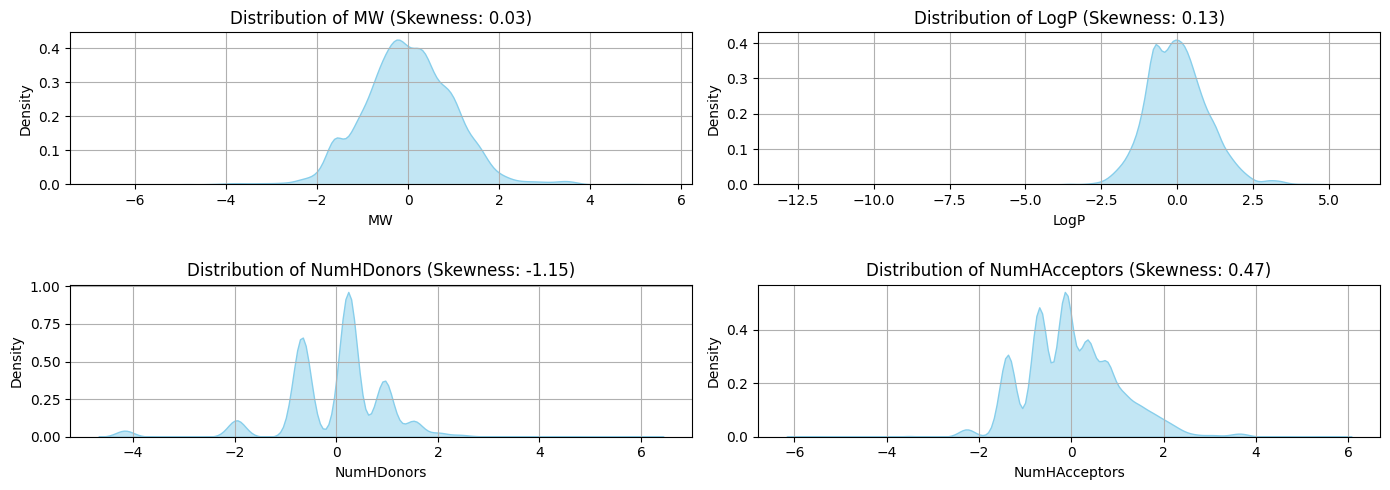

In [25]:
fig, axes = plt.subplots(nrows=(len(numerical_cols) + 1) // 2, ncols=2, figsize=(14, 2.5 * ((len(numerical_cols) + 1) // 2)))
axes = axes.flatten()
for i, column in enumerate(numerical_cols):
    skewness = stats.skew(features_df[column])  # Calculate skewness
    
    # Plot histogram for visual inspection
    sns.kdeplot(features_df[column], ax=axes[i], color='skyblue', fill=True, alpha=0.5)
    axes[i].set_title(f'Distribution of {column} (Skewness: {skewness:.2f})')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Density')
    axes[i].grid()
    plt.tight_layout(h_pad=2.5)
plt.show()

In [26]:
features_df[numerical_cols].head(3)

,MW,LogP,NumHDonors,NumHAcceptors
0,0.483099,0.219236,0.943334,0.344859
1,0.648027,0.570605,0.943334,0.344859
2,0.067137,-0.028334,0.943334,-0.692281


In [27]:
df_cleaned.head(3)

,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class_inactive
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4,6,8.6,False
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4,6,9.0,False
2,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,415.449,3.5662,4,4,9.0,False


##### RDKit

In [14]:
from rdkit.Chem import AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdFingerprintGenerator
from rdkit import Chem

features = []

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1000)
    
for idx, row in features_df.iterrows():
    # Convert SMILES to molecule object
    smile= row['canonical_smiles']
    mol = Chem.MolFromSmiles(smile)
    
    if mol:
        # Compute Morgan Fingerprints (ECFP)
        fingerprint = morgan_gen.GetFingerprint(mol)
        fingerprint_array = list(fingerprint)  # Convert to list
        
        # Compute bmolecular descriptors
        # molb_weight = Descriptors.MolWt(mol)  # Molecular Weight
        # logp = Descriptors.MolLogP(mol)  # LogP (Lipophilicity)
        # tpsa = Descriptors.TPSA(mol)  # Topological Polar Surface Area
        
        # Collect features (fingerprint + descriptors)
        features.append(fingerprint_array + [row['MW'], row['LogP'], row['NumHDonors'],
                                                row['NumHAcceptors']])

# Convert the features into a pandas DataFrame
X = pd.DataFrame(features)


##### DeepChem

In [27]:
%pip install deepchem

import deepchem as dc
from rdkit import Chem

# Use DeepChem's MolGraphConvFeaturizer to convert SMILES to molecular graph features
featurizer = dc.feat.MolGraphConvFeaturizer()

# This will create a list of graph features for each molecule
features_df['molecular_graph'] = features_df['canonical_smiles'].apply(lambda x: featurizer.featurize([x])[0])

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\BioActivity\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\BioActivity\.venv\Lib\site-packages\deepchem\feat\smiles_tokenizer.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


ModuleNotFoundError: No module named 'tensorflow'

In [40]:
features_df=features_df.drop(['canonical_smiles'], axis=1)

In [42]:
features_df.head(3)

,MW,LogP,NumHDonors,NumHAcceptors,molecular_graph
0,0.483099,0.219236,0.943334,0.344859,"GraphData(node_features=[34, 30], edge_index=[..."
1,0.648027,0.570605,0.943334,0.344859,"GraphData(node_features=[36, 30], edge_index=[..."
2,0.067137,-0.028334,0.943334,-0.692281,"GraphData(node_features=[31, 30], edge_index=[..."


In [44]:
features_df["graph_features"] = [graph.node_features for graph in features_df['molecular_graph']]
features_df.drop(['molecular_graph'], axis=1, inplace=True)
features_df.head(3)

,MW,LogP,NumHDonors,NumHAcceptors,graph_features
0,0.483099,0.219236,0.943334,0.344859,"[[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
1,0.648027,0.570605,0.943334,0.344859,"[[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
2,0.067137,-0.028334,0.943334,-0.692281,"[[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


##### ChemBERTa

In [49]:
from transformers import BertModel, AutoTokenizer
import torch

# Load pretrained ChemBERTa model (PyTorch version)
model = BertModel.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")
tokenizer = AutoTokenizer.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")

# Encode the SMILES string into embeddings
def get_chemberta_embedding(smiles):
    inputs = tokenizer(smiles, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).detach().numpy()

features_df['chemberta_embedding'] = features_df['canonical_smiles'].apply(get_chemberta_embedding)


You are using a model of type roberta to instantiate a model of type bert. This is not supported for all configurations of models and can yield errors.
Some weights of BertModel were not initialized from the model checkpoint at seyonec/ChemBERTa-zinc-base-v1 and are newly initialized: ['embeddings.LayerNorm.bias', 'embeddings.LayerNorm.weight', 'embeddings.position_embeddings.weight', 'embeddings.token_type_embeddings.weight', 'embeddings.word_embeddings.weight', 'encoder.layer.0.attention.output.LayerNorm.bias', 'encoder.layer.0.attention.output.LayerNorm.weight', 'encoder.layer.0.attention.output.dense.bias', 'encoder.layer.0.attention.output.dense.weight', 'encoder.layer.0.attention.self.key.bias', 'encoder.layer.0.attention.self.key.weight', 'encoder.layer.0.attention.self.query.bias', 'encoder.layer.0.attention.self.query.weight', 'encoder.layer.0.attention.self.value.bias', 'encoder.layer.0.attention.self.value.weight', 'encoder.layer.0.intermediate.dense.bias', 'encoder.layer.0.

In [50]:
features_df.head(3)

,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,chemberta_embedding
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,0.483099,0.219236,0.943334,0.344859,"[[-0.23707804, 0.49395293, 0.24604033, 0.39372..."
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,0.648027,0.570605,0.943334,0.344859,"[[-0.2607426, 0.5720752, 0.30183813, 0.4454808..."
2,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,0.067137,-0.028334,0.943334,-0.692281,"[[-0.22725658, 0.40469354, 0.2657733, 0.412880..."


In [52]:
features_df['chemberta_embedding'][0].shape

(1, 768)

In [53]:
X=features_df.drop(['canonical_smiles'], axis=1)

In [54]:
X = X.set_index(features_df.index)
y = target_df.loc[features_df.index]

In [57]:
print(X.shape, y.shape)

(6341, 5) (6341,)


In [58]:
X

,MW,LogP,NumHDonors,NumHAcceptors,chemberta_embedding
0,0.483099,0.219236,0.943334,0.344859,"[[-0.23707804, 0.49395293, 0.24604033, 0.39372..."
1,0.648027,0.570605,0.943334,0.344859,"[[-0.2607426, 0.5720752, 0.30183813, 0.4454808..."
2,0.067137,-0.028334,0.943334,-0.692281,"[[-0.22725658, 0.40469354, 0.2657733, 0.412880..."
3,-1.616230,-0.785634,0.234994,-1.380096,"[[0.020684434, 0.4703463, 0.16719496, 0.629871..."
4,-0.674613,0.532985,0.234994,-0.692281,"[[-0.27644372, 0.5241341, 0.23280697, 0.511133..."
...,...,...,...,...,...
6336,-0.556850,-0.909211,0.234994,-0.130294,"[[-0.3302253, 0.6001225, 0.21501105, 0.2417253..."
6337,-1.616230,-0.785634,0.234994,-1.380096,"[[-0.30155748, 0.66687113, 0.18498448, 0.31351..."
6338,-0.023540,0.483125,0.234994,0.756455,"[[-0.23910008, 0.5743231, 0.25488824, 0.486559..."
6339,-1.616230,-0.785634,0.234994,-1.380096,"[[-0.38627326, 0.6163624, 0.15096714, 0.402964..."


In [61]:
first_embedding = np.array(X['chemberta_embedding'].iloc[0])
print(f"Shape of a single embedding: {first_embedding.shape}")

Shape of a single embedding: (1, 768)


In [64]:
def squeeze_embedding(embedding_list):
    """
    Squeezes a pre-pooled embedding of shape (1, d) into shape (d,)
    """
    return np.array(embedding_list).squeeze() # .squeeze() removes dimensions of size 1

# Apply the function to the whole column
X['squeezed_embedding'] = X['chemberta_embedding'].apply(squeeze_embedding)

# 3. Create the final feature set
# Get the traditional features
traditional_features = X[['MW', 'LogP', 'NumHDonors', 'NumHAcceptors']].values

# Stack the squeezed embeddings into a matrix
embedding_matrix = np.vstack(X['squeezed_embedding'].values)

# Combine them by concatenating the columns
final_feature_matrix = np.hstack((traditional_features, embedding_matrix))

print(f"Traditional features shape: {traditional_features.shape}")
print(f"Embedding matrix shape: {embedding_matrix.shape}")
print(f"Final combined feature matrix shape: {final_feature_matrix.shape}")

Traditional features shape: (6341, 4)
Embedding matrix shape: (6341, 768)
Final combined feature matrix shape: (6341, 772)


In [89]:
# Extract the embeddings and convert them into a usable format (e.g., an array)
embeddings = np.array(X['chemberta_embedding'].tolist())
embeddings.shape

(6341, 1, 768)

#### Model Training

##### Data Fecthing

In [145]:
numerical_cols = ['MW', 'LogP', 'NumHDonors', 'NumHAcceptors']  

In [146]:
cleaned_df=pd.read_excel("bioactivity_dataset_cleaned_outliers.xlsx")
cleaned_df.head(2)

,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class,bioactivity
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4,6,8.6,active,1
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4,6,9.0,active,1


In [147]:
features_df = cleaned_df.drop(['bioactivity_class', 'bioactivity','pIC50'], axis=1)
target_df = cleaned_df['bioactivity']

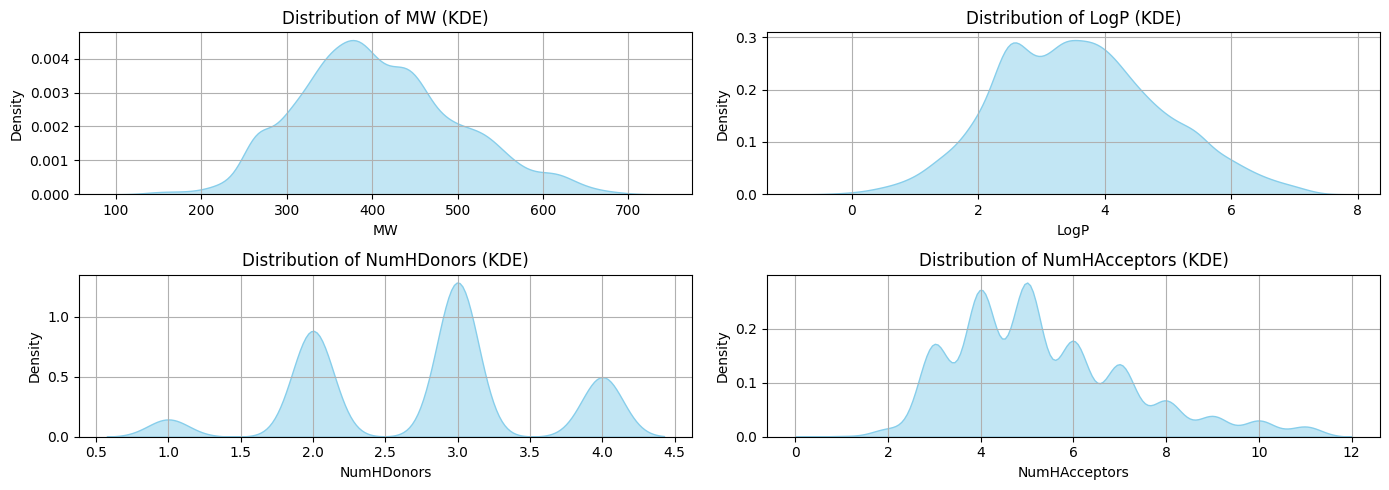

In [148]:
fig, axes = plt.subplots(nrows=(len(numerical_cols) + 1) // 2, ncols=2, figsize=(14, 2.5 * ((len(numerical_cols) + 1) // 2)))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].set_title(f'Distribution of {col} (KDE)')
    sns.kdeplot(features_df[col], ax=axes[i], color='skyblue', fill=True, alpha=0.5)
    axes[i].set_ylabel('Density')
    axes[i].grid()
    axes[i].set_xlabel(col)
plt.tight_layout()
plt.show()

In [149]:
from rdkit.Chem import AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdFingerprintGenerator
from rdkit import Chem

features = []

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1000)
    
for idx, row in features_df.iterrows():
    # Convert SMILES to molecule object
    smile= row['canonical_smiles']
    mol = Chem.MolFromSmiles(smile)
    
    if mol:
        # Compute Morgan Fingerprints (ECFP)
        fingerprint = morgan_gen.GetFingerprint(mol)
        fingerprint_array = list(fingerprint)  # Convert to list
        
        # Compute bmolecular descriptors
        # molb_weight = Descriptors.MolWt(mol)  # Molecular Weight
        # logp = Descriptors.MolLogP(mol)  # LogP (Lipophilicity)
        # tpsa = Descriptors.TPSA(mol)  # Topological Polar Surface Area
        
        # Collect features (fingerprint + descriptors)
        features.append(fingerprint_array + [row['MW'], row['LogP'], row['NumHDonors'],
                                                row['NumHAcceptors']])

# Convert the features into a pandas DataFrame
X = pd.DataFrame(features)
X.shape

(5667, 1004)

In [150]:
len(features_df), len(target_df)

(5667, 5667)

In [151]:
X = X.set_index(features_df.index)
y = target_df.loc[features_df.index]

In [152]:
X.head(3)

,0,1,2,3,4,5,6,7,8,9,...,994,995,996,997,998,999,1000,1001,1002,1003
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,464.522,3.9242,4,6
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,485.544,4.4323,4,6
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,415.449,3.5662,4,4


##### Train Test Split

In [153]:

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from sklearn.preprocessing import StandardScaler

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Feature scaling (needed for some base estimators)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

X_train, y_train = SMOTETomek(random_state=42).fit_resample(X_train, y_train)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)



(7410, 1004) (7410,)
(567, 1004) (567,)
(567, 1004) (567,)


In [154]:
print(y_train.value_counts())
print(y_val.value_counts())
print(y_test.value_counts())

bioactivity
0    3705
1    3705
Name: count, dtype: int64
bioactivity
1    454
0    113
Name: count, dtype: int64
bioactivity
1    475
0     92
Name: count, dtype: int64


In [157]:
y_train.value_counts()

bioactivity
0    3705
1    3705
Name: count, dtype: int64

##### Statistical Testing

In [165]:
from scipy.stats import ttest_ind

print("Performing t-test for descriptor significance...")
p_values = {}
for col in numerical_cols:
    group0 = stat_x_train[y_train == 0][col]
    group1 = stat_x_train[y_train == 1][col]
    t_stat, p_val = ttest_ind(group0, group1, nan_policy='omit')
    p_values[col] = p_val
    mean0 = group0.mean()
    mean1 = group1.mean()
    print(f"{col}: Inactive mean = {mean0:.2f}, Active mean = {mean1:.2f}, t-stat = {t_stat}, p-value = {p_val:.50f}")
significant_features = [col for col, p_val in p_values.items() if p_val < 0.05]
print("Significant descriptors (p < 0.05):", significant_features)

Performing t-test for descriptor significance...
MW: Inactive mean = 384.06, Active mean = 412.27, t-stat = -7.929430306884161, p-value = 0.00000000000000275145131835954474550281135104262090
LogP: Inactive mean = 3.32, Active mean = 3.65, t-stat = -6.585409091955932, p-value = 0.00000000005052847655803682222579238952619984630993
NumHDonors: Inactive mean = 2.40, Active mean = 2.84, t-stat = -14.674640494949276, p-value = 0.00000000000000000000000000000000000000000000001146
NumHAcceptors: Inactive mean = 4.98, Active mean = 5.43, t-stat = -6.258437968457921, p-value = 0.00000000042480063954437979746893145997777008204821
Significant descriptors (p < 0.05): ['MW', 'LogP', 'NumHDonors', 'NumHAcceptors']


In [166]:
y_train[y_train==0].value_counts().sum()/y_train.value_counts().sum()

np.float64(0.18111625854842267)

Generating t-SNE visualization...


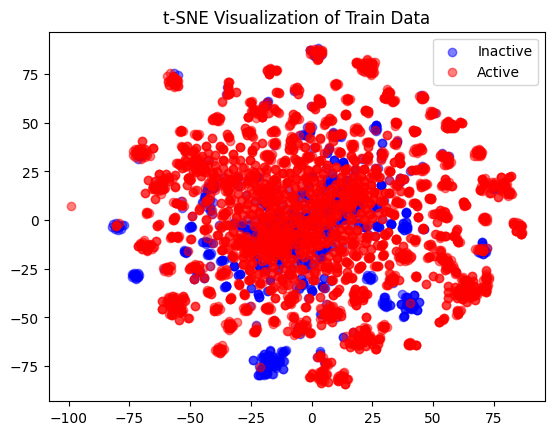

In [180]:
from sklearn.manifold import TSNE
print("Generating t-SNE visualization...")
# Use all features (embeddings + descriptors) for visualization
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_train)
plt.scatter(X_tsne[y_train == 0, 0], X_tsne[y_train == 0, 1], label="Inactive", alpha=0.5, c='blue')
plt.scatter(X_tsne[y_train == 1, 0], X_tsne[y_train == 1, 1], label="Active", alpha=0.5, c='red')
plt.legend()
plt.title("t-SNE Visualization of Train Data")
plt.show()

e:\ML\BioActivity\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning:

Graph is not fully connected, spectral embedding may not work as expected.

e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning:

Graph is not fully connected, spectral embedding may not work as expected.



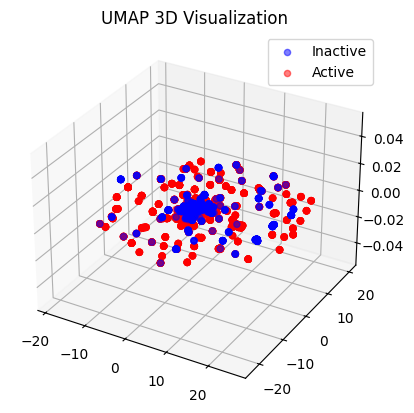

In [193]:
from umap.umap_ import UMAP
umap_model = UMAP(n_components=2, n_neighbors=7, min_dist=0.1, random_state=42)
X_umap = umap_model.fit_transform(X_train)
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_umap[y_train == 0, 0], X_umap[y_train == 0, 1],  c='blue', label="Inactive", alpha=0.5)
ax.scatter(X_umap[y_train == 1, 0], X_umap[y_train == 1, 1], c='red', label="Active", alpha=0.5)
ax.legend()
plt.title("UMAP 3D Visualization")
plt.show()

##### Utilities

In [94]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix,
    average_precision_score
)


def calc_metrics(final_model):
    y_prob = final_model.predict_proba(X_test)[:, 1]  # Probabilities for positive class
    y_pred = final_model.predict(X_test)  # Binary predictions (threshold at 0.5)

    # Step 2: Compute metrics
    accuracy = accuracy_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)  # This is also Sensitivity
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    mcc = matthews_corrcoef(y_test, y_pred)
    auprc = average_precision_score(y_test, y_prob)  # Area Under Precision-Recall Curve

    # For Specificity: Derive from confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity = recall  # Same as recall

    # Step 3: Print or store results (e.g., to fill your table)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Balanced Acc.: {balanced_acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"MCC: {mcc:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"Sensitivity: {sensitivity:.4f}")
    print(f"AUPRC: {auprc:.4f}")

In [95]:
from sklearn.metrics import log_loss
import numpy as np
import torch
import torch.nn as nn

# Focal Loss for Imbalanced Data (Test Set)

# Focal Loss implementation (binary classification)
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        BCE_loss = nn.BCEWithLogitsLoss(reduction='none')(inputs, targets)
        pt = torch.exp(-BCE_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * BCE_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        else:
            return focal_loss.sum()
        
def calc_loss(final_model):
    # Calculate log loss
    log_loss_value = log_loss(y_test, final_model.predict_proba(X_test))
    print("Log Loss(Test):", log_loss_value)

    log_loss_value = log_loss(y_train, final_model.predict_proba(X_train))
    print("Log Loss(Train):", log_loss_value)


    # Get predicted probabilities for the positive class
    y_proba = final_model.predict_proba(X_test)[:, 1]
    # Convert to logits (inverse of sigmoid)
    eps = 1e-8  # to avoid log(0)
    logits = np.log(y_proba / (1 - y_proba + eps) + eps)

    # Convert to torch tensors
    logits_tensor = torch.tensor(logits, dtype=torch.float32)
    targets_tensor = torch.tensor(y_test.values, dtype=torch.float32)

    # Calculate focal loss
    focal_loss_fn = FocalLoss(alpha=0.25, gamma=2.0)
    focal_loss_value = focal_loss_fn(logits_tensor, targets_tensor)
    print(f'Focal Loss (Test Set): {focal_loss_value.item():.4f}')

In [96]:
def plot_confusion_matrix(final_model):
    y_pred = final_model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

In [110]:
from pathlib import Path
import joblib
import json

Path("saved_model/ml_models/sampling").mkdir(parents=True, exist_ok=True)

def save_model(final_model, best_params, model_name):
    # Save the trained model (with compression)
    joblib.dump(final_model, f"saved_model/ml_models/sampling/{model_name}.pkl", compress=3)

    # Save simple metadata (e.g., columns and best params) for reproducibility
    metadata = {
        "model_type": type(final_model).__name__,
        "best_params": best_params if 'best_params' in globals() else None
    }
    with open(f"saved_model/ml_models/sampling/{model_name}_metadata.json", "w") as f:
        json.dump(metadata, f, indent=2)

    print("Model and metadata saved to saved_model/ml_models/sampling/")

In [111]:
def shap_plot(final_model):
    import shap

    # Create a SHAP explainer
    #explainer = shap.TreeExplainer(final_model, X_train)
    explainer = shap.Explainer(final_model, X_train)

    # Calculate SHAP values for the test set
    shap_values = explainer.shap_values(X_test)

    # Plot summary plot
    #shap.summary_plot(shap_values, X_test, plot_type="bar")

    #emb_idx = slice(0, 1000)  # e.g., 0:1000
    #desc_idx = slice(1000, 1004)

    #print("Desc Index: " ,desc_idx)

    #explainer = shap.TreeExplainer(final_model)
    #shap_values = explainer.shap_values(X_test)  # Shape: [n_samples, n_features]

    # Overall importance
    #mean_abs_shap = np.abs(shap_values).mean(0)
    #print("Embedding total importance:", mean_abs_shap[emb_idx].sum())
    #print("Descriptors importance:", mean_abs_shap[desc_idx])

    plt.figure(figsize=(8,8))
    shap.summary_plot(shap_values, X_test)  # Clean plot!



In [112]:
from lime.lime_tabular import LimeTabularExplainer

def lime_plot(final_model):
    def predict_proba_wrapper(X):
        return final_model.predict_proba(X)

    explainer = LimeTabularExplainer(
        X_train, 
        class_names=["0", "1"], 
        mode="classification"
    )


    exp = explainer.explain_instance(
        X_test[0], 
        predict_proba_wrapper,
        num_features=10
    )

    # OPTION 2: Show as matplotlib figure
    fig = exp.as_pyplot_figure()
    plt.tight_layout()
    plt.show()

    # OPTION 3: Print as text
    print("\nFeature contributions:")
    print(exp.as_list())

    # OPTION 4: Get as dictionary
    print("\nExplanation as dict:")
    print(exp.as_map())


##### XGBoost

In [158]:
import optuna
import warnings
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

warnings.filterwarnings("ignore")


neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"Class imbalance ratio: {scale_pos_weight:.2f}:1\n")


def objective(trial):
    param = {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 50, 500, step=50),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-2, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-2, 10.0, log=True),
        #"scale_pos_weight": trial.suggest_float("scale_pos_weight", scale_pos_weight * 0.5, scale_pos_weight * 1.5),
        "booster": trial.suggest_categorical("booster", ["gbtree", "gblinear", "dart"]),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "n_jobs": -1
        
    }
    # model = xgb.XGBClassifier(**param)
    # model.fit(X_train, y_train)
    # pred_prob = model.predict_proba(X_val)[:, 1]
    # auc = roc_auc_score(y_val, pred_prob)
    # return 1.0 - auc  # Optuna minimizes, so invert accuracy

    if param["booster"] == "gblinear":
        param.pop("max_depth", None)
        param.pop("min_child_weight", None)
        param.pop("subsample", None)
        param.pop("colsample_bytree", None)
    elif param["booster"] == "dart":
        param["rate_drop"] = trial.suggest_float("rate_drop", 1e-3, 0.2, log=True)
        param["skip_drop"] = trial.suggest_float("skip_drop", 1e-3, 0.2, log=True)
    
    # Convert to DMatrix for XGBoost
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
    
    # Train model with early stopping
    model = xgb.train(
        param,
        dtrain,
        evals=[(dval, "validation")],
        early_stopping_rounds=10,
        num_boost_round=param["n_estimators"],
        verbose_eval=False
    )
    
    # Predict probabilities for AUC
    preds_proba = model.predict(dval)
    auc = roc_auc_score(y_val, preds_proba)
    
    return 1.0 - auc  # Optuna minimizes, so invert AUC

study = optuna.create_study()
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Best trial:")
print(study.best_trial)
print("Best params:", study.best_params)

# Train final model with best params
best_params_xgb = study.best_params
best_params_xgb.update({"objective": "binary:logistic", "eval_metric": "auc", "use_label_encoder": False})
final_model_xgb = xgb.XGBClassifier(**best_params_xgb)
final_model_xgb.fit(X_train, y_train)
y_pred = final_model_xgb.predict(X_test)
print("Final Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

[I 2025-10-25 20:39:28,780] A new study created in memory with name: no-name-ce4011ce-6da9-4018-8126-7c45774066e4


Class imbalance ratio: 1.00:1



Best trial: 0. Best value: 0.5:   2%|▏         | 1/50 [00:00<00:05,  9.16it/s]

[I 2025-10-25 20:39:28,888] Trial 0 finished with value: 0.5 and parameters: {'max_depth': 7, 'learning_rate': 0.04036779815116747, 'n_estimators': 200, 'subsample': 0.6294006594060573, 'colsample_bytree': 0.9353334522610497, 'gamma': 2.068255736224992, 'reg_alpha': 0.33078620563181615, 'reg_lambda': 3.37528787661943, 'booster': 'gblinear', 'min_child_weight': 7}. Best is trial 0 with value: 0.5.


Best trial: 2. Best value: 0.158902:   6%|▌         | 3/50 [00:00<00:10,  4.27it/s]

...

[I 2025-10-25 20:41:34,089] Trial 46 finished with value: 0.06535807570854935 and parameters: {'max_depth': 7, 'learning_rate': 0.09758949859741348, 'n_estimators': 150, 'subsample': 0.9566554876664473, 'colsample_bytree': 0.997738720620958, 'gamma': 1.0682132610256725, 'reg_alpha': 0.38789658510131614, 'reg_lambda': 1.5942937544921243, 'booster': 'gbtree', 'min_child_weight': 2}. Best is trial 43 with value: 0.06196639507231683.


Best trial: 43. Best value: 0.0619664:  96%|█████████▌| 48/50 [02:06<00:02,  1.10s/it]

[I 2025-10-25 20:41:35,243] Trial 47 finished with value: 0.06551401504814636 and parameters: {'max_depth': 8, 'learning_rate': 0.11000110310044749, 'n_estimators': 200, 'subsample': 0.9569131949860067, 'colsample_bytree': 0.9753423457698567, 'gamma': 1.0730853944604322, 'reg_alpha': 0.37658751031163906, 'reg_lambda': 1.5945708149724083, 'booster': 'gbtree', 'min_child_weight': 1}. Best is trial 43 with value: 0.06196639507231683.


Best trial: 43. Best value: 0.0619664: 100%|██████████| 50/50 [02:10<00:00,  2.60s/it]


[I 2025-10-25 20:41:38,897] Trial 48 finished with value: 0.06231725858640991 and parameters: {'max_depth': 7, 'learning_rate': 0.034254020355333654, 'n_estimators': 300, 'subsample': 0.9676284950514137, 'colsample_bytree': 0.9966674424122262, 'gamma': 0.739683236082691, 'reg_alpha': 0.25738146416541097, 'reg_lambda': 0.0863517543477798, 'booster': 'gbtree', 'min_child_weight': 2}. Best is trial 43 with value: 0.06196639507231683.
[I 2025-10-25 20:41:39,005] Trial 49 finished with value: 0.5 and parameters: {'max_depth': 8, 'learning_rate': 0.008898401522862627, 'n_estimators': 350, 'subsample': 0.911931777769807, 'colsample_bytree': 0.9485562731101694, 'gamma': 0.7146612158164074, 'reg_alpha': 0.28353826544665156, 'reg_lambda': 0.07729205349400585, 'booster': 'gblinear', 'min_child_weight': 1}. Best is trial 43 with value: 0.06196639507231683.
Best trial:
FrozenTrial(number=43, state=1, values=[0.06196639507231683], datetime_start=datetime.datetime(2025, 10, 25, 20, 41, 30, 106966), d

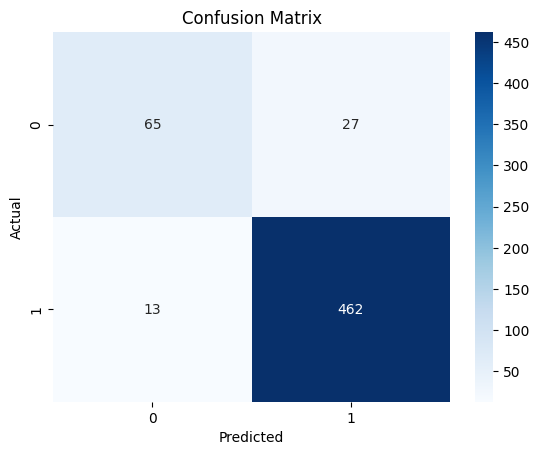

In [159]:
plot_confusion_matrix(final_model_xgb)

In [160]:
calc_metrics(final_model_xgb)

Accuracy: 0.9295
Balanced Acc.: 0.8396
Precision: 0.9448
Recall: 0.9726
F1 Score: 0.9585
ROC-AUC: 0.9395
MCC: 0.7270
Specificity: 0.7065
Sensitivity: 0.9726
AUPRC: 0.9837


In [161]:
calc_loss(final_model_xgb)

Log Loss(Test): 0.20714849419248357
Log Loss(Train): 0.06686477799903574
Focal Loss (Test Set): 0.0278


In [162]:
save_model(final_model_xgb, best_params_xgb, "xgboost_bioactivity_model")

Model and metadata saved to saved_model/ml_models/sampling/


<Figure size 500x300 with 0 Axes>

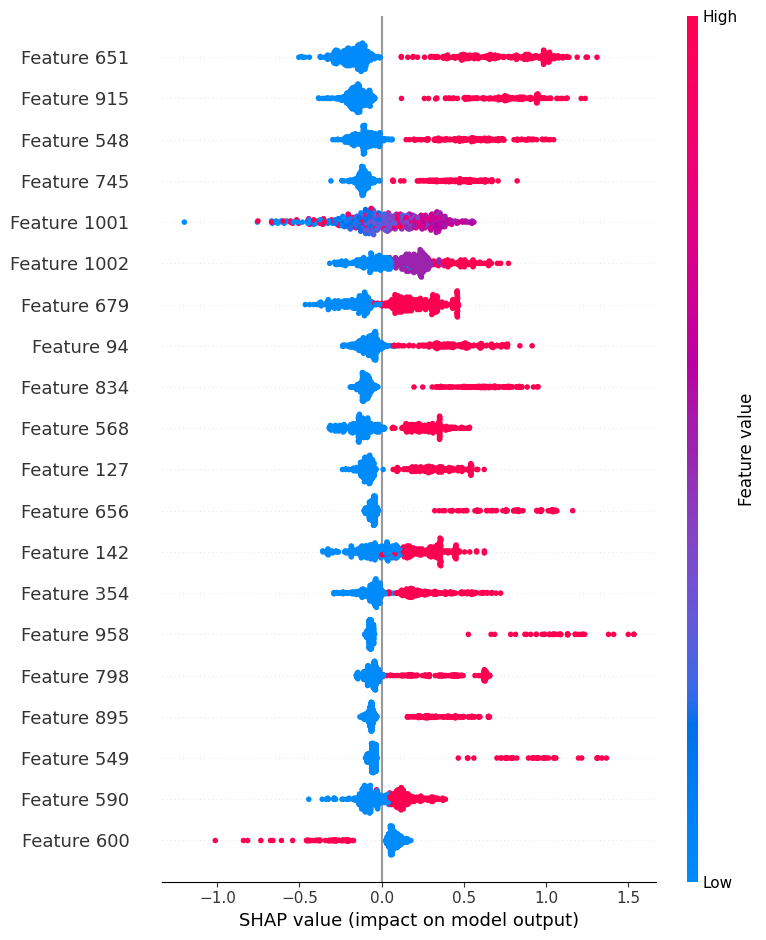

In [163]:
plt.figure(figsize=(5, 3)) 
shap_plot(final_model_xgb)

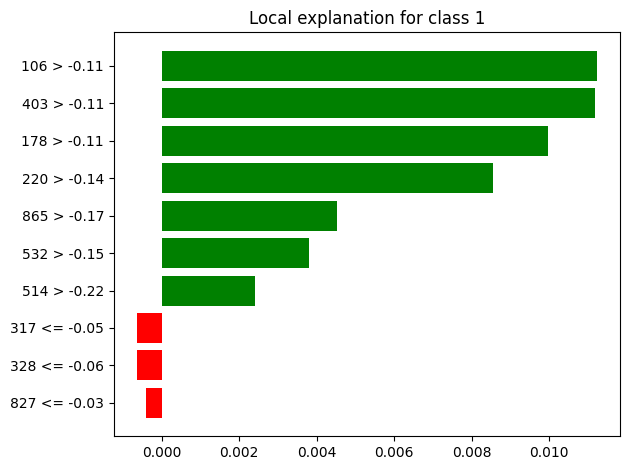


Feature contributions:
[('106 > -0.11', 0.011240679552671653), ('403 > -0.11', 0.011191146590664594), ('178 > -0.11', 0.009971275411823364), ('220 > -0.14', 0.00856734164323598), ('865 > -0.17', 0.00453056215533727), ('532 > -0.15', 0.003790307947952671), ('514 > -0.22', 0.002412777775419842), ('317 <= -0.05', -0.0006481103452450533), ('328 <= -0.06', -0.0006373961842100501), ('827 <= -0.03', -0.0004081588675035551)]

Explanation as dict:
{1: [(106, 0.011240679552671653), (403, 0.011191146590664594), (178, 0.009971275411823364), (220, 0.00856734164323598), (865, 0.00453056215533727), (532, 0.003790307947952671), (514, 0.002412777775419842), (317, -0.0006481103452450533), (328, -0.0006373961842100501), (827, -0.0004081588675035551)]}


In [164]:
lime_plot(final_model_xgb)

#### RandomForest

In [165]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def objective(trial):

    
    param = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None, 0.5, 1]),
        "max_samples": trial.suggest_float("max_samples", 0.5, 1.0),
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy"]),
        "class_weight": trial.suggest_categorical("class_weight", ["balanced", "balanced_subsample", None]),
        "random_state": 42
    }
   
    model = RandomForestClassifier(**param, n_jobs=-1)
    model.fit(X_train, y_train)

    # Evaluate on the validation set and compute ROC AUC using the positive-class probabilities
    preds_proba = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, preds_proba)
    return 1.0 - auc  # Optuna minimizes, so invert AUC

study = optuna.create_study()
study.optimize(objective, n_trials=50)

print("Best trial:")
print(study.best_trial)
print("Best params:", study.best_params)

# Train final model with best params
best_params_rf = study.best_params
final_model_rf = RandomForestClassifier(**best_params_rf, n_jobs=-1)
final_model_rf.fit(X_train, y_train)
y_pred = final_model_rf.predict(X_test)
print("Final Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

[I 2025-10-25 20:41:44,714] A new study created in memory with name: no-name-3c2bc68f-197e-4c2a-a4fe-f29b2eda2e44
[I 2025-10-25 20:41:47,102] Trial 0 finished with value: 0.18795563525788472 and parameters: {'n_estimators': 237, 'max_depth': 4, 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': None, 'max_samples': 0.8106386277836879, 'criterion': 'entropy', 'class_weight': 'balanced_subsample'}. Best is trial 0 with value: 0.18795563525788472.
[I 2025-10-25 20:41:47,905] Trial 1 finished with value: 0.1273049783634166 and parameters: {'n_estimators': 225, 'max_depth': 7, 'min_samples_split': 3, 'min_samples_leaf': 7, 'max_features': 'log2', 'max_samples': 0.5657594888155807, 'criterion': 'gini', 'class_weight': 'balanced_subsample'}. Best is trial 1 with value: 0.1273049783634166.
[I 2025-10-25 20:41:49,799] Trial 2 finished with value: 0.05935441113406881 and parameters: {'n_estimators': 254, 'max_depth': 12, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 

Best trial:
FrozenTrial(number=12, state=1, values=[0.04703520330591415], datetime_start=datetime.datetime(2025, 10, 25, 20, 41, 57, 40172), datetime_complete=datetime.datetime(2025, 10, 25, 20, 41, 58, 364035), params={'n_estimators': 346, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_samples': 0.7164161918952235, 'criterion': 'entropy', 'class_weight': None}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=500, log=False, low=50, step=1), 'max_depth': IntDistribution(high=20, log=False, low=3, step=1), 'min_samples_split': IntDistribution(high=10, log=False, low=2, step=1), 'min_samples_leaf': IntDistribution(high=10, log=False, low=1, step=1), 'max_features': CategoricalDistribution(choices=('sqrt', 'log2', None, 0.5, 1)), 'max_samples': FloatDistribution(high=1.0, log=False, low=0.5, step=None), 'criterion': CategoricalDistribution(choices=('gini', 'entropy')), 'class_weight':

Text(95.72222222222221, 0.5, 'Actual')

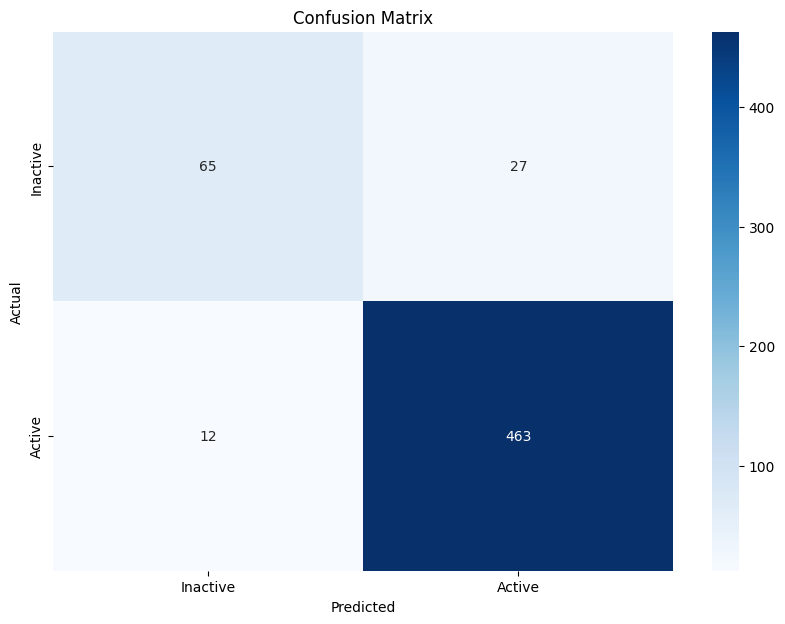

In [166]:
conf_matrix = confusion_matrix(y_test, y_pred)

import seaborn as sns
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Inactive', 'Active'], yticklabels=['Inactive', 'Active'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [167]:
calc_metrics(final_model_rf)

Accuracy: 0.9312
Balanced Acc.: 0.8406
Precision: 0.9449
Recall: 0.9747
F1 Score: 0.9596
ROC-AUC: 0.9592
MCC: 0.7332
Specificity: 0.7065
Sensitivity: 0.9747
AUPRC: 0.9914


In [168]:
calc_loss(final_model_rf)

Log Loss(Test): 0.20604489373854146
Log Loss(Train): 0.07689575886090251
Focal Loss (Test Set): 0.0151


In [169]:
save_model(final_model_rf, best_params_rf, "random_forest_bioactivity_model")

Model and metadata saved to saved_model/ml_models/sampling/


 99%|===================| 1122/1134 [01:05<00:00]        

<Figure size 800x800 with 0 Axes>

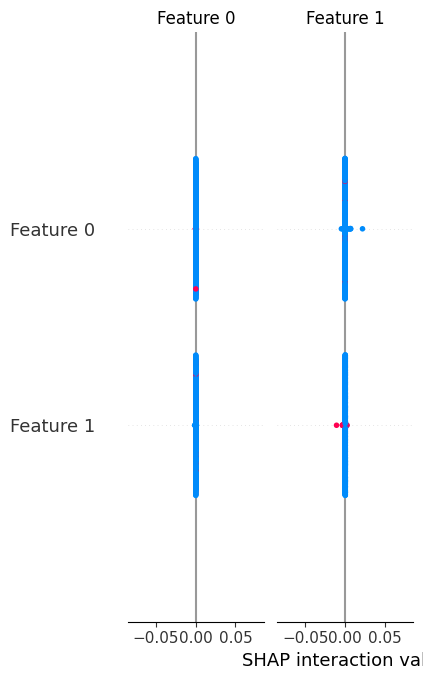

In [170]:
shap_plot(final_model_rf)

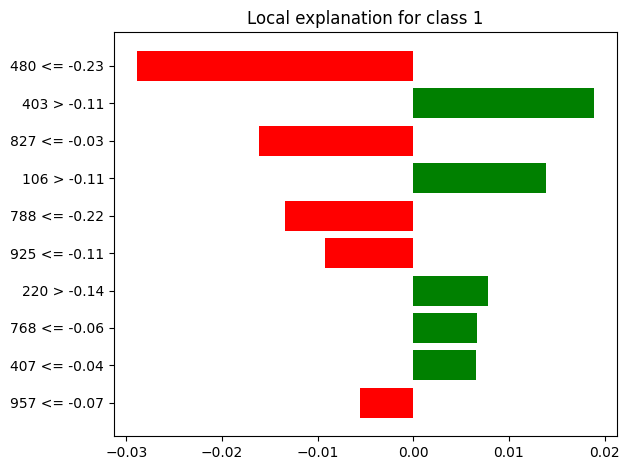


Feature contributions:
[('480 <= -0.23', -0.028924489520025375), ('403 > -0.11', 0.018886429315585408), ('827 <= -0.03', -0.01609585880098062), ('106 > -0.11', 0.013883515145007703), ('788 <= -0.22', -0.0133908517766349), ('925 <= -0.11', -0.009186760862559366), ('220 > -0.14', 0.007783222681938025), ('768 <= -0.06', 0.0066297134895935755), ('407 <= -0.04', 0.006521141600533226), ('957 <= -0.07', -0.005595795233625956)]

Explanation as dict:
{1: [(480, -0.028924489520025375), (403, 0.018886429315585408), (827, -0.01609585880098062), (106, 0.013883515145007703), (788, -0.0133908517766349), (925, -0.009186760862559366), (220, 0.007783222681938025), (768, 0.0066297134895935755), (407, 0.006521141600533226), (957, -0.005595795233625956)]}


In [171]:
lime_plot(final_model_rf)

#### LightGBM

In [172]:
import optuna
import lightgbm as lgbm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def objective(trial):
    param = {
        "objective": "binary",
        "metric": "auc",
        "verbosity": -1,
        "boosting_type": trial.suggest_categorical("boosting_type", ["gbdt", "goss", "rf"]),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "num_leaves": trial.suggest_int("num_leaves", 7, 128),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 50, 500, step=50),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-2, 10.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-2, 10.0, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 10.0),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 100, step=10),
    }
    if param["boosting_type"] == "goss":
        param["top_rate"] = trial.suggest_float("top_rate", 0.1, 0.4)
        param["other_rate"] = trial.suggest_float("other_rate", 0.05, 0.3)
    elif param["boosting_type"] == "rf":
        param["bagging_freq"] = trial.suggest_int("bagging_freq", 1, 10)
        param["bagging_fraction"] = trial.suggest_float("bagging_fraction", 0.5, 1.0)
    
    # Convert to Dataset for LightGBM
    train_data = lgbm.Dataset(X_train, label=y_train)
    val_data = lgbm.Dataset(X_val, label=y_val)
    
    # Train model with early stopping
    model = lgbm.train(
        param,
        train_data,
        valid_sets=[val_data],
        num_boost_round=param["n_estimators"]
    )
    
    # Predict probabilities for AUC
    preds_proba = model.predict(X_val)
    auc = roc_auc_score(y_val, preds_proba)

    return 1.0-auc

study = optuna.create_study()
study.optimize(objective, n_trials=50)

print("Best trial:")
print(study.best_trial)
print("Best params:", study.best_params)

# Train final model with best params
best_params_lgbm = study.best_params
best_params_lgbm.update({"objective": "binary", "metric": "auc", "verbosity": -1})
final_model_lgbm = lgbm.LGBMClassifier(**best_params_lgbm)
final_model_lgbm.fit(X_train, y_train)
y_pred = final_model_lgbm.predict(X_test)
print("Final AUC:", roc_auc_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

[I 2025-10-25 20:43:44,476] A new study created in memory with name: no-name-bdf0b74b-a8fd-409d-bae7-201651334355
[I 2025-10-25 20:43:46,105] Trial 0 finished with value: 0.13923433784257944 and parameters: {'boosting_type': 'rf', 'max_depth': 7, 'num_leaves': 106, 'learning_rate': 0.12095795518229924, 'n_estimators': 200, 'subsample': 0.7514725853835577, 'colsample_bytree': 0.5783725507447801, 'reg_lambda': 1.6834344819440938, 'reg_alpha': 0.022810916399510838, 'min_child_samples': 18, 'scale_pos_weight': 3.2618509906067095, 'min_data_in_leaf': 20, 'bagging_freq': 8, 'bagging_fraction': 0.9344858911410514}. Best is trial 0 with value: 0.13923433784257944.
[I 2025-10-25 20:43:47,860] Trial 1 finished with value: 0.07360336828973535 and parameters: {'boosting_type': 'goss', 'max_depth': 11, 'num_leaves': 26, 'learning_rate': 0.03164832216998725, 'n_estimators': 500, 'subsample': 0.7200495882045195, 'colsample_bytree': 0.5119416663313214, 'reg_lambda': 0.017733704313714935, 'reg_alpha': 

Best trial:
FrozenTrial(number=43, state=1, values=[0.04508596156095279], datetime_start=datetime.datetime(2025, 10, 25, 20, 44, 48, 454385), datetime_complete=datetime.datetime(2025, 10, 25, 20, 44, 49, 882015), params={'boosting_type': 'gbdt', 'max_depth': 7, 'num_leaves': 108, 'learning_rate': 0.21854006910083046, 'n_estimators': 200, 'subsample': 0.5848638269698467, 'colsample_bytree': 0.5317812640540027, 'reg_lambda': 0.36846674942394736, 'reg_alpha': 0.7477549645937906, 'min_child_samples': 19, 'scale_pos_weight': 5.319264835767538, 'min_data_in_leaf': 20}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'boosting_type': CategoricalDistribution(choices=('gbdt', 'goss', 'rf')), 'max_depth': IntDistribution(high=12, log=False, low=3, step=1), 'num_leaves': IntDistribution(high=128, log=False, low=7, step=1), 'learning_rate': FloatDistribution(high=0.3, log=True, low=0.001, step=None), 'n_estimators': IntDistribution(high=500, log=False, low=50, step=50), 'sub

In [173]:
calc_metrics(final_model_lgbm)

Accuracy: 0.9259
Balanced Acc.: 0.8199
Precision: 0.9374
Recall: 0.9768
F1 Score: 0.9567
ROC-AUC: 0.9574
MCC: 0.7086
Specificity: 0.6630
Sensitivity: 0.9768
AUPRC: 0.9905


In [174]:
calc_loss(final_model_lgbm)

Log Loss(Test): 0.23141224214272288
Log Loss(Train): 0.015161301100127316
Focal Loss (Test Set): 0.0466


In [175]:
save_model(final_model_lgbm, best_params_lgbm, "lightgbm_bioactivity_model")

Model and metadata saved to saved_model/ml_models/sampling/


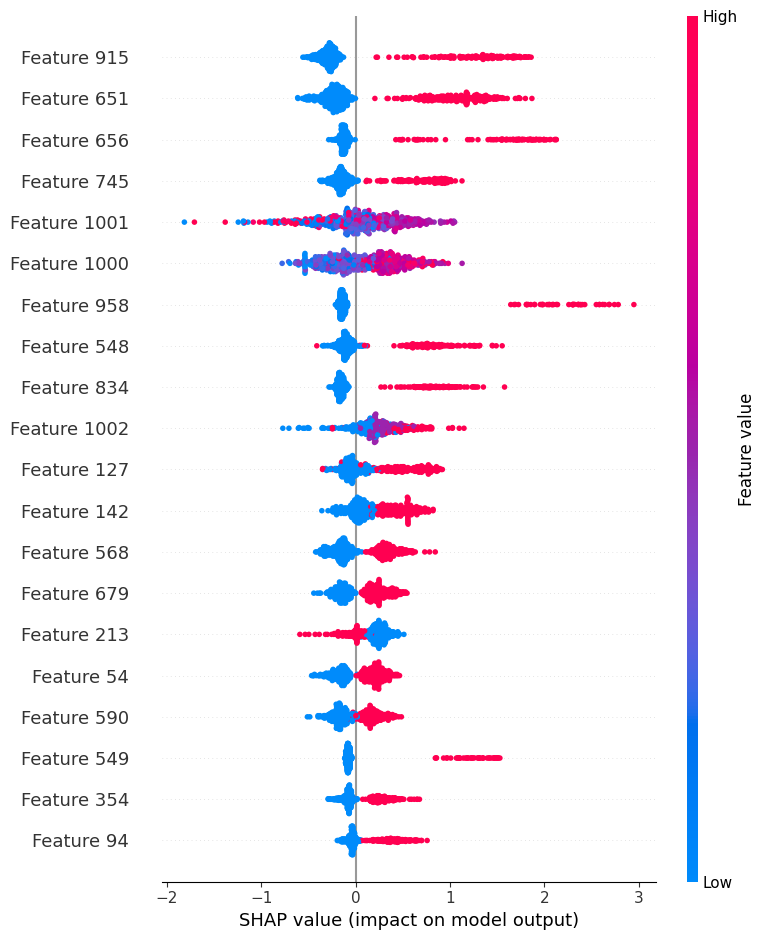

In [176]:
shap_plot(final_model_lgbm)

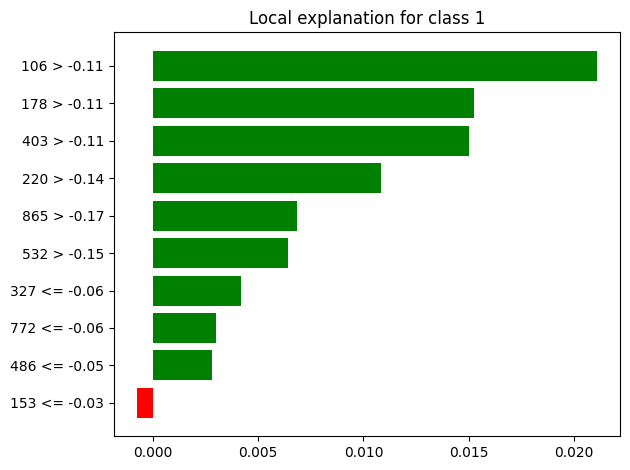


Feature contributions:
[('106 > -0.11', 0.02107866876259466), ('178 > -0.11', 0.01526727884349716), ('403 > -0.11', 0.014998776256786538), ('220 > -0.14', 0.010847607304283396), ('865 > -0.17', 0.006867534546051411), ('532 > -0.15', 0.006410046333449292), ('327 <= -0.06', 0.004179299315492315), ('772 <= -0.06', 0.002986334001743588), ('486 <= -0.05', 0.0028339998127707316), ('153 <= -0.03', -0.0007531080590865062)]

Explanation as dict:
{1: [(106, 0.02107866876259466), (178, 0.01526727884349716), (403, 0.014998776256786538), (220, 0.010847607304283396), (865, 0.006867534546051411), (532, 0.006410046333449292), (327, 0.004179299315492315), (772, 0.002986334001743588), (486, 0.0028339998127707316), (153, -0.0007531080590865062)]}


In [177]:
lime_plot(final_model_lgbm)

### CatBoost

In [178]:
import optuna
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def objective(trial):
    param = {
        "objective": "Logloss",
        "eval_metric": "AUC",
        "verbose": False,
        "boosting_type": "Plain",  # or "Ordered" for better quality but slower
        "depth": trial.suggest_int("depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "iterations": trial.suggest_int("iterations", 10, 500),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1),
        "random_strength": trial.suggest_float("random_strength", 0, 2),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 0.5, 5.0),
        "thread_count": -1
    }
    model = CatBoostClassifier(**param)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)])
    preds = model.predict_proba(X_val)[:,1]
    auc = roc_auc_score(y_val, preds)

    return 1.0 - auc  # Optuna minimizes, so invert AUC

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print("Best trial:")
print(study.best_trial)
print("Best params:", study.best_params)

# Train final model with best params
best_params_cat = study.best_params
best_params_cat.update({
    "objective": "Logloss",
    "eval_metric": "AUC",
    "verbose": False,
    "boosting_type": "Plain"
})
final_model_cat = CatBoostClassifier(**best_params_cat)
final_model_cat.fit(X_train, y_train)
y_pred = final_model_cat.predict(X_test)
print("Final Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

[I 2025-10-25 20:45:04,036] A new study created in memory with name: no-name-07e19f78-e8e5-44e9-9e38-b47b87a7b8e9
[I 2025-10-25 20:45:06,529] Trial 0 finished with value: 0.19682468519745822 and parameters: {'depth': 3, 'learning_rate': 0.0340690487025932, 'iterations': 69, 'l2_leaf_reg': 1.1541024066975796, 'bagging_temperature': 0.0246185477073243, 'random_strength': 1.0422163800088502, 'border_count': 170, 'scale_pos_weight': 4.1596828536202235}. Best is trial 0 with value: 0.19682468519745822.
[I 2025-10-25 20:45:12,536] Trial 1 finished with value: 0.11026860551245576 and parameters: {'depth': 5, 'learning_rate': 0.014789688816701872, 'iterations': 451, 'l2_leaf_reg': 8.639680753599702, 'bagging_temperature': 0.19914448014190622, 'random_strength': 1.7878210086849764, 'border_count': 50, 'scale_pos_weight': 2.3121955882457925}. Best is trial 1 with value: 0.11026860551245576.
[I 2025-10-25 20:47:54,075] Trial 2 finished with value: 0.04999805075825503 and parameters: {'depth': 12,

Best trial:
FrozenTrial(number=10, state=1, values=[0.04268839421465054], datetime_start=datetime.datetime(2025, 10, 25, 20, 50, 32, 743608), datetime_complete=datetime.datetime(2025, 10, 25, 20, 52, 22, 55118), params={'depth': 12, 'learning_rate': 0.2514541060008315, 'iterations': 166, 'l2_leaf_reg': 3.7034809559613238, 'bagging_temperature': 0.9966358832548473, 'random_strength': 1.4110635457587855, 'border_count': 251, 'scale_pos_weight': 0.5604550727365817}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'depth': IntDistribution(high=12, log=False, low=3, step=1), 'learning_rate': FloatDistribution(high=0.3, log=True, low=0.001, step=None), 'iterations': IntDistribution(high=500, log=False, low=10, step=1), 'l2_leaf_reg': FloatDistribution(high=10.0, log=False, low=1.0, step=None), 'bagging_temperature': FloatDistribution(high=1.0, log=False, low=0.0, step=None), 'random_strength': FloatDistribution(high=2.0, log=False, low=0.0, step=None), 'border_count': 

In [179]:
calc_metrics(final_model_cat)

Accuracy: 0.9312
Balanced Acc.: 0.8669
Precision: 0.9561
Recall: 0.9621
F1 Score: 0.9591
ROC-AUC: 0.9564
MCC: 0.7438
Specificity: 0.7717
Sensitivity: 0.9621
AUPRC: 0.9891


In [180]:
calc_loss(final_model_cat)

Log Loss(Test): 0.19221472422545455
Log Loss(Train): 0.01076520952293445
Focal Loss (Test Set): 0.0328


In [181]:
save_model(final_model_cat, best_params_cat, "catboost_bioactivity_model")

Model and metadata saved to saved_model/ml_models/sampling/


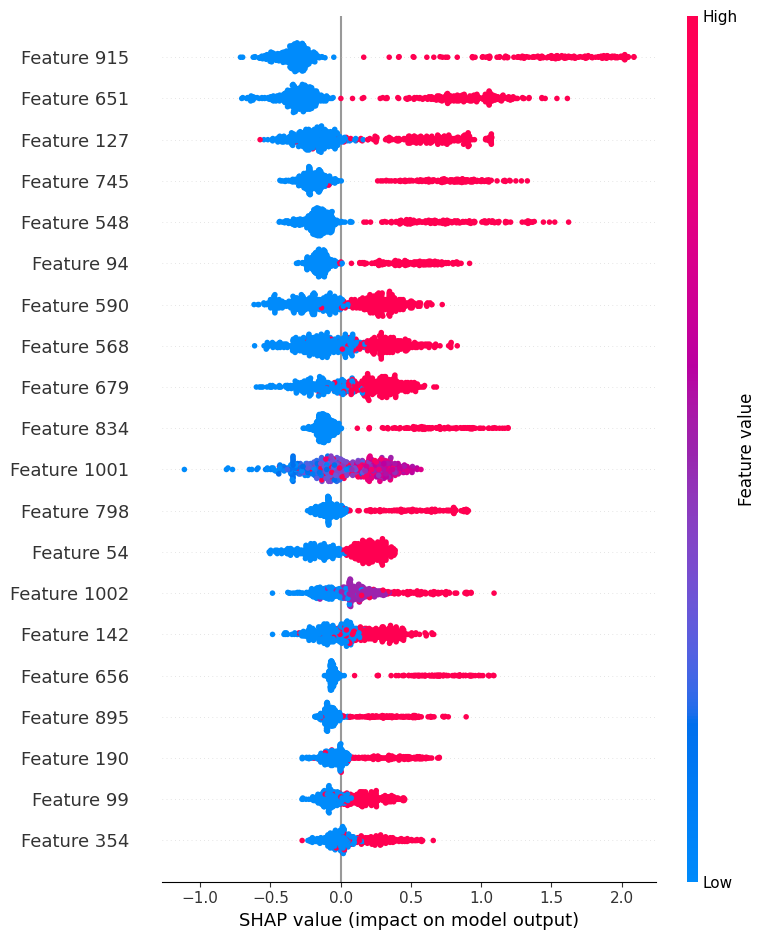

In [182]:
shap_plot(final_model_cat) 

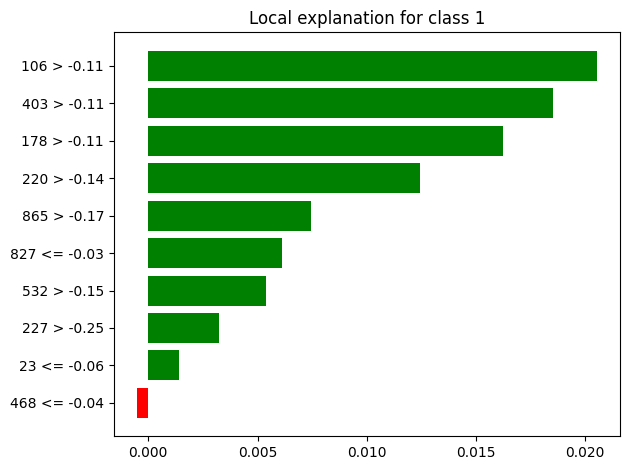


Feature contributions:
[('106 > -0.11', 0.020541599200455955), ('403 > -0.11', 0.018519406061611256), ('178 > -0.11', 0.016219008695448137), ('220 > -0.14', 0.01243006430305773), ('865 > -0.17', 0.007437381504114144), ('827 <= -0.03', 0.006111529575584929), ('532 > -0.15', 0.005371405059383536), ('227 > -0.25', 0.003232593383340616), ('23 <= -0.06', 0.0014030473213850635), ('468 <= -0.04', -0.0005296961002413925)]

Explanation as dict:
{1: [(106, 0.020541599200455955), (403, 0.018519406061611256), (178, 0.016219008695448137), (220, 0.01243006430305773), (865, 0.007437381504114144), (827, 0.006111529575584929), (532, 0.005371405059383536), (227, 0.003232593383340616), (23, 0.0014030473213850635), (468, -0.0005296961002413925)]}


In [183]:
lime_plot(final_model_cat)

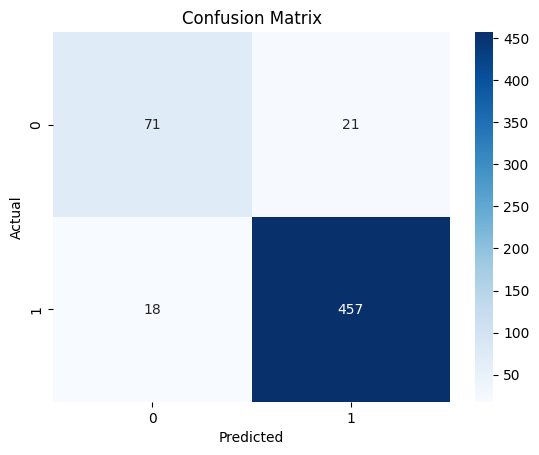

In [184]:
plot_confusion_matrix(final_model_cat)

### ExtraTree Classifier

In [185]:
import optuna
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
from sklearn.model_selection import cross_val_score
import numpy as np

# Calculate class imbalance (if needed)
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"Class imbalance ratio: {scale_pos_weight:.2f}:1")

def objective(trial):
    """
    Objective function for Optuna to optimize ExtraTreesClassifier
    """
    
    param = {
        # Number of trees in the forest
        "n_estimators": trial.suggest_int("n_estimators", 10, 500),
        
        # Maximum depth of the tree
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        
        # Minimum samples required to split an internal node
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        
        # Minimum samples required at a leaf node
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        
        # Number of features to consider when looking for the best split
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None, 0.3, 0.5, 0.7, 1.0]),
        
        # Whether to use bootstrap samples
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        
        # --- CLASS IMBALANCE HANDLING ---
        # Option 1: Use automatic balancing
        "class_weight": trial.suggest_categorical("class_weight", ["balanced", "balanced_subsample", None]),
        
        # Option 2: Use fixed calculated weight (uncomment and comment out Option 1)
        # "class_weight": {0: 1.0, 1: scale_pos_weight},
        
        # Option 3: Tune the minority class weight (uncomment and comment out Option 1)
        # "class_weight": {0: 1.0, 1: trial.suggest_float("minority_weight", 1.0, 10.0)},
        
        # --- ADDITIONAL PARAMETERS ---
        # Minimum weighted fraction of samples required at leaf
        "min_weight_fraction_leaf": trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.1),
        
        # Maximum number of leaf nodes
        "max_leaf_nodes": trial.suggest_categorical("max_leaf_nodes", [None, 10, 20, 50, 100]),
        
        # Minimum impurity decrease for split
        "min_impurity_decrease": trial.suggest_float("min_impurity_decrease", 0.0, 0.2),
        
        # Complexity parameter for pruning
        "ccp_alpha": trial.suggest_float("ccp_alpha", 0.0, 0.1),
        
        # Maximum number of samples when bootstrap is True
        "max_samples": trial.suggest_float("max_samples", 0.5, 1.0) if trial.params.get("bootstrap", True) else None,
        
        # Quality of split criterion
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy"]),
        
        # Other settings
        "random_state": 42,
        "n_jobs": -1,  # Use all CPU cores
        "warm_start": False,
        "oob_score": False  # Out-of-bag score (only if bootstrap=True)
    }
    
    # Remove max_samples if bootstrap is False
    if not param["bootstrap"]:
        param.pop("max_samples", None)
    
    # Build and train model
    model = ExtraTreesClassifier(**param)
    model.fit(X_train, y_train)
    
    # Predict probabilities for AUC calculation
    preds_proba = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, preds_proba)

    # Alternative: Use accuracy
    # preds = model.predict(X_test)
    # accuracy = accuracy_score(y_test, preds)
    # return 1.0 - accuracy
    
    # Alternative: Use F1 score
    # preds = model.predict(X_test)
    # f1 = f1_score(y_test, preds)
    # return 1.0 - f1
    
    return 1.0 - auc  # Optuna minimizes


def objective_with_cv(trial):
    """
    Objective function with cross-validation for more robust evaluation
    """
    
    param = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "class_weight": trial.suggest_categorical("class_weight", ["balanced", "balanced_subsample", None]),
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy"]),
        "random_state": 42,
        "n_jobs": -1
    }
    
    model = ExtraTreesClassifier(**param)
    
    # 5-fold cross-validation
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
    
    return 1.0 - scores.mean()


# Create study and optimize
print("Starting hyperparameter optimization...")
study = optuna.create_study(
    direction="minimize",
    study_name="extratrees_optimization",
    sampler=optuna.samplers.TPESampler(seed=42)
)

# Run optimization
study.optimize(objective, n_trials=50, show_progress_bar=True)

# Print results
print("\n" + "="*50)
print("OPTIMIZATION RESULTS")
print("="*50)
print(f"Best trial: {study.best_trial.number}")
print(f"Best AUC: {1 - study.best_value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# Train final model with best parameters
print("\n" + "="*50)
print("TRAINING FINAL MODEL")
print("="*50)

best_params_et = study.best_params.copy()
best_params_et.update({
    "random_state": 42,
    "n_jobs": -1
})

final_model_et = ExtraTreesClassifier(**best_params_et)
final_model_et.fit(X_train, y_train)

# Evaluate final model
y_pred = final_model_et.predict(X_test)
y_pred_proba = final_model_et.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(f"\nFinal Model Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"  F1 Score: {f1_score(y_test, y_pred):.4f}")


print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature importance
print(f"\nTop 10 Most Important Features:")
feature_importance = final_model_et.feature_importances_
feature_names = X_train.columns if hasattr(X_train, 'columns') else [f"Feature_{i}" for i in range(X_train.shape[1])]
importance_df = sorted(zip(feature_names, feature_importance), key=lambda x: x[1], reverse=True)
for name, importance in importance_df[:10]:
    print(f"  {name}: {importance:.4f}")

# Optuna visualization (optional)
try:
    import plotly
    
    # Plot optimization history
    fig1 = optuna.visualization.plot_optimization_history(study)
    fig1.write_html("optuna_history.html")
    
    # Plot parameter importances
    fig2 = optuna.visualization.plot_param_importances(study)
    fig2.write_html("optuna_param_importances.html")
    
    # Plot parallel coordinate
    fig3 = optuna.visualization.plot_parallel_coordinate(study)
    fig3.write_html("optuna_parallel_coordinate.html")
    
    print("\nOptuna visualizations saved as HTML files!")
except ImportError:
    print("\nInstall plotly for visualizations: pip install plotly")

[I 2025-10-25 21:12:00,965] A new study created in memory with name: extratrees_optimization


Class imbalance ratio: 1.00:1
Starting hyperparameter optimization...


Best trial: 0. Best value: 0.408785:   2%|▏         | 1/50 [00:00<00:27,  1.78it/s]

[I 2025-10-25 21:12:01,540] Trial 0 finished with value: 0.40878523254454013 and parameters: {'n_estimators': 193, 'max_depth': 29, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 0.3, 'bootstrap': True, 'class_weight': 'balanced', 'min_weight_fraction_leaf': 0.030424224295953775, 'max_leaf_nodes': 50, 'min_impurity_decrease': 0.058428929707043636, 'ccp_alpha': 0.03663618432936917, 'max_samples': 0.728034992108518, 'criterion': 'gini'}. Best is trial 0 with value: 0.40878523254454013.


Best trial: 0. Best value: 0.408785:   4%|▍         | 2/50 [00:01<00:44,  1.07it/s]

...

[I 2025-10-25 21:13:41,901] Trial 46 finished with value: 0.37443959299832363 and parameters: {'n_estimators': 157, 'max_depth': 30, 'min_samples_split': 11, 'min_samples_leaf': 7, 'max_features': 'log2', 'bootstrap': False, 'class_weight': 'balanced_subsample', 'min_weight_fraction_leaf': 0.02431002194370188, 'max_leaf_nodes': 50, 'min_impurity_decrease': 0.048544788711246845, 'ccp_alpha': 0.02431195739581001, 'criterion': 'entropy'}. Best is trial 22 with value: 0.1495263342559744.
[I 2025-10-25 21:13:42,047] Trial 47 finished with value: 0.31729757124478586 and parameters: {'n_estimators': 20, 'max_depth': 27, 'min_samples_split': 13, 'min_samples_leaf': 6, 'max_features': 'log2', 'bootstrap': False, 'class_weight': 'balanced_subsample', 'min_weight_fraction_leaf': 0.03249872131309153, 'max_leaf_nodes': 50, 'min_impurity_decrease': 0.011973333672686423, 'ccp_alpha': 0.013198341383925172, 'criterion': 'entropy'}. Best is trial 22 with value: 0.1495263342559744.


Best trial: 22. Best value: 0.149526:  98%|█████████▊| 49/50 [01:41<00:00,  2.23it/s]

[I 2025-10-25 21:13:42,295] Trial 48 finished with value: 0.5 and parameters: {'n_estimators': 76, 'max_depth': 22, 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': False, 'class_weight': 'balanced_subsample', 'min_weight_fraction_leaf': 0.015683535170144043, 'max_leaf_nodes': 50, 'min_impurity_decrease': 0.06801035501748763, 'ccp_alpha': 0.018943178857348926, 'criterion': 'entropy'}. Best is trial 22 with value: 0.1495263342559744.


Best trial: 22. Best value: 0.149526: 100%|██████████| 50/50 [01:41<00:00,  2.04s/it]


[I 2025-10-25 21:13:42,846] Trial 49 finished with value: 0.5 and parameters: {'n_estimators': 258, 'max_depth': 25, 'min_samples_split': 12, 'min_samples_leaf': 5, 'max_features': 'log2', 'bootstrap': False, 'class_weight': 'balanced_subsample', 'min_weight_fraction_leaf': 0.021566540611310976, 'max_leaf_nodes': 50, 'min_impurity_decrease': 0.02739216688169508, 'ccp_alpha': 0.09935628686602364, 'criterion': 'entropy'}. Best is trial 22 with value: 0.1495263342559744.

OPTIMIZATION RESULTS
Best trial: 22
Best AUC: 0.8505

Best hyperparameters:
  n_estimators: 434
  max_depth: 5
  min_samples_split: 18
  min_samples_leaf: 10
  max_features: None
  bootstrap: True
  class_weight: balanced_subsample
  min_weight_fraction_leaf: 0.011210108744296149
  max_leaf_nodes: None
  min_impurity_decrease: 0.0001236837284415821
  ccp_alpha: 0.0008376664592552275
  max_samples: 0.9558991976398594
  criterion: gini

TRAINING FINAL MODEL

Final Model Performance:
  Accuracy: 0.8219
  ROC-AUC: 0.8711
  F

In [186]:
calc_metrics(final_model_et)

Accuracy: 0.8219
Balanced Acc.: 0.7929
Precision: 0.9452
Recall: 0.8358
F1 Score: 0.8872
ROC-AUC: 0.8711
MCC: 0.4928
Specificity: 0.7500
Sensitivity: 0.8358
AUPRC: 0.9675


In [187]:
calc_loss(final_model_et)

Log Loss(Test): 0.4248696281669205
Log Loss(Train): 0.3825913706892533
Focal Loss (Test Set): 0.0297


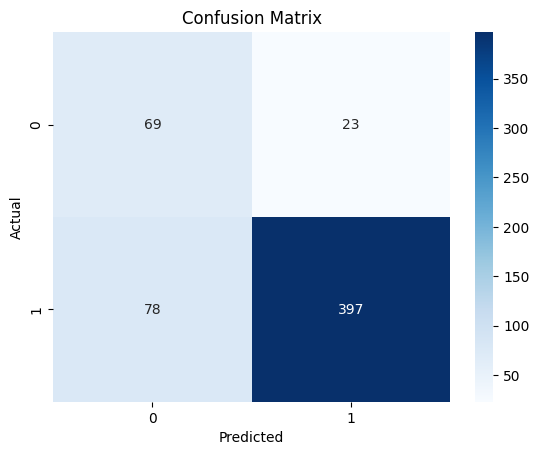

In [188]:
plot_confusion_matrix(final_model_et)

In [189]:
save_model(final_model_et, best_params_et, "extratree_bioactivity_model")

Model and metadata saved to saved_model/ml_models/sampling/


<Figure size 800x800 with 0 Axes>

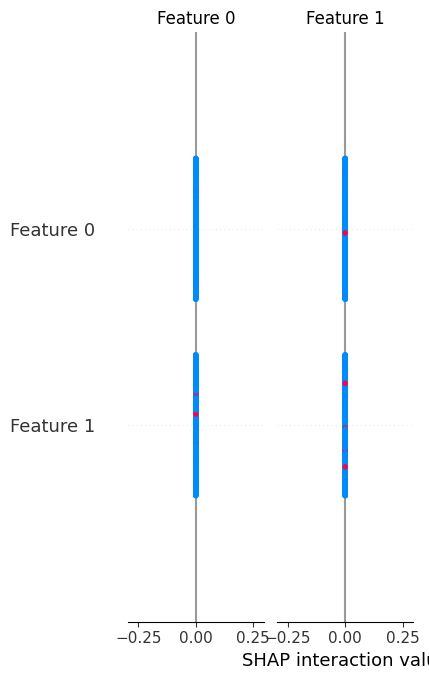

In [190]:
shap_plot(final_model_et)

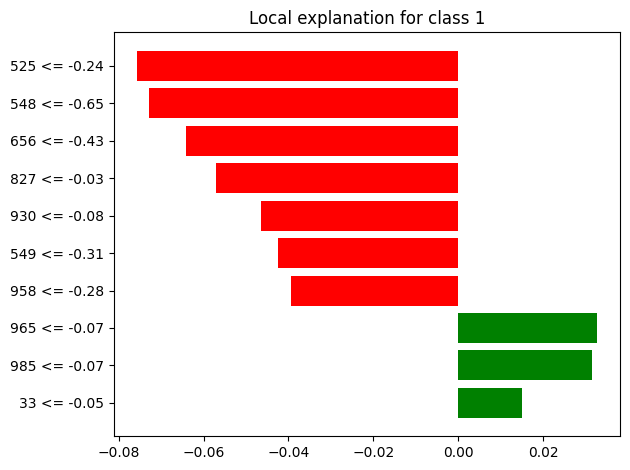


Feature contributions:
[('525 <= -0.24', -0.07574366751068252), ('548 <= -0.65', -0.07299384511398563), ('656 <= -0.43', -0.06425028004681789), ('827 <= -0.03', -0.057013951507116925), ('930 <= -0.08', -0.04644438938664849), ('549 <= -0.31', -0.0425745337105574), ('958 <= -0.28', -0.039367677697887946), ('965 <= -0.07', 0.03273332446612187), ('985 <= -0.07', 0.03147324099924973), ('33 <= -0.05', 0.015132033700433362)]

Explanation as dict:
{1: [(525, -0.07574366751068252), (548, -0.07299384511398563), (656, -0.06425028004681789), (827, -0.057013951507116925), (930, -0.04644438938664849), (549, -0.0425745337105574), (958, -0.039367677697887946), (965, 0.03273332446612187), (985, 0.03147324099924973), (33, 0.015132033700433362)]}


In [191]:
lime_plot(final_model_et)

#### CNN

In [192]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [193]:
# Calculate class weights for imbalance
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
class_weights = torch.tensor([1.0, neg_count / pos_count], dtype=torch.float32).to(device)
print(f"Class imbalance ratio: {neg_count / pos_count:.2f}:1")

Class imbalance ratio: 1.00:1


In [194]:
class CNN1D(nn.Module):
    """
    1D CNN for tabular data classification
    """
    def __init__(self, input_size, trial):
        super(CNN1D, self).__init__()
        
        # Hyperparameters from Optuna
        n_conv_layers = trial.suggest_int("n_conv_layers", 1, 4)
        n_fc_layers = trial.suggest_int("n_fc_layers", 1, 3)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)
        
        # Build convolutional layers
        conv_layers = []
        in_channels = 1
        current_size = input_size
        
        for i in range(n_conv_layers):
            out_channels = trial.suggest_int(f"conv_{i}_out_channels", 16, 128, step=16)
            kernel_size = trial.suggest_int(f"conv_{i}_kernel_size", 3, 7, step=2)
            
            conv_layers.append(nn.Conv1d(in_channels, out_channels, kernel_size, padding=kernel_size//2))
            conv_layers.append(nn.BatchNorm1d(out_channels))
            conv_layers.append(nn.ReLU())
            conv_layers.append(nn.Dropout(dropout_rate))
            
            # Optional pooling
            if trial.suggest_categorical(f"conv_{i}_pooling", [True, False]):
                pool_size = trial.suggest_int(f"conv_{i}_pool_size", 2, 3)
                conv_layers.append(nn.MaxPool1d(pool_size))
                current_size = current_size // pool_size
            
            in_channels = out_channels
        
        self.conv_block = nn.Sequential(*conv_layers)
        
        # Calculate flattened size
        flattened_size = out_channels * current_size
        
        # Build fully connected layers
        fc_layers = []
        prev_size = flattened_size
        
        for i in range(n_fc_layers):
            fc_size = trial.suggest_int(f"fc_{i}_size", 32, 512, step=32)
            fc_layers.append(nn.Linear(prev_size, fc_size))
            fc_layers.append(nn.ReLU())
            fc_layers.append(nn.Dropout(dropout_rate))
            prev_size = fc_size
        
        # Output layer
        fc_layers.append(nn.Linear(prev_size, 2))
        
        self.fc_block = nn.Sequential(*fc_layers)
    
    def forward(self, x):
        x = x.unsqueeze(1)  # Add channel dimension: (batch, features) -> (batch, 1, features)
        x = self.conv_block(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc_block(x)
        return x

In [195]:
class CNN2D(nn.Module):
    """
    2D CNN for image-like data classification
    Assumes input is reshaped to (batch, channels, height, width)
    """
    def __init__(self, input_channels, input_height, input_width, trial):
        super(CNN2D, self).__init__()
        
        # Hyperparameters from Optuna
        n_conv_layers = trial.suggest_int("n_conv_layers", 2, 5)
        n_fc_layers = trial.suggest_int("n_fc_layers", 1, 3)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)
        
        # Build convolutional layers
        conv_layers = []
        in_channels = input_channels
        current_h, current_w = input_height, input_width
        
        for i in range(n_conv_layers):
            out_channels = trial.suggest_int(f"conv_{i}_out_channels", 16, 128, step=16)
            kernel_size = trial.suggest_int(f"conv_{i}_kernel_size", 3, 7, step=2)
            
            conv_layers.append(nn.Conv2d(in_channels, out_channels, kernel_size, padding=kernel_size//2))
            conv_layers.append(nn.BatchNorm2d(out_channels))
            conv_layers.append(nn.ReLU())
            conv_layers.append(nn.Dropout2d(dropout_rate))
            
            # Pooling
            if trial.suggest_categorical(f"conv_{i}_pooling", [True, False]):
                pool_size = trial.suggest_int(f"conv_{i}_pool_size", 2, 3)
                conv_layers.append(nn.MaxPool2d(pool_size))
                current_h = current_h // pool_size
                current_w = current_w // pool_size
            
            in_channels = out_channels
        
        self.conv_block = nn.Sequential(*conv_layers)
        
        # Calculate flattened size
        flattened_size = out_channels * current_h * current_w
        
        # Build fully connected layers
        fc_layers = []
        prev_size = flattened_size
        
        for i in range(n_fc_layers):
            fc_size = trial.suggest_int(f"fc_{i}_size", 64, 512, step=64)
            fc_layers.append(nn.Linear(prev_size, fc_size))
            fc_layers.append(nn.ReLU())
            fc_layers.append(nn.Dropout(dropout_rate))
            prev_size = fc_size
        
        # Output layer
        fc_layers.append(nn.Linear(prev_size, 2))
        
        self.fc_block = nn.Sequential(*fc_layers)
    
    def forward(self, x):
        x = self.conv_block(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc_block(x)
        return x

In [196]:

def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    
    for batch_X, batch_y in dataloader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    
    return total_loss / len(dataloader)


def evaluate(model, dataloader, device):
    """Evaluate model"""
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for batch_X, batch_y in dataloader:
            batch_X = batch_X.to(device)
            outputs = model(batch_X)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)
            
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch_y.numpy())
    
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


In [197]:
def objective_1d(trial):
    """
    Objective function for 1D CNN (for tabular data)
    """
    
    # Prepare data
    X_train_tensor = torch.FloatTensor(X_train.values if hasattr(X_train, 'values') else X_train)
    y_train_tensor = torch.LongTensor(y_train.values if hasattr(y_train, 'values') else y_train)
    X_val_tensor = torch.FloatTensor(X_val.values if hasattr(X_val, 'values') else X_val)
    y_val_tensor = torch.LongTensor(y_val.values if hasattr(y_val, 'values') else y_val)
    X_test_tensor = torch.FloatTensor(X_test.values if hasattr(X_test, 'values') else X_test)
    y_test_tensor = torch.LongTensor(y_test.values if hasattr(y_test, 'values') else y_test)
    
    # Hyperparameters
    batch_size = trial.suggest_int("batch_size", 16, 128, step=16)
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    n_epochs = trial.suggest_int("n_epochs", 10, 100)
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "AdamW", "SGD", "RMSprop"])
    
    # Create dataloaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Create model
    input_size = X_train_tensor.shape[1]
    model = CNN1D(input_size, trial).to(device)
    
    # Loss function with class weights
    use_class_weights = trial.suggest_categorical("use_class_weights", [True, False])
    if use_class_weights:
        criterion = nn.CrossEntropyLoss(weight=class_weights)
    else:
        criterion = nn.CrossEntropyLoss()
    
    # Optimizer
    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    elif optimizer_name == "AdamW":
        optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    elif optimizer_name == "SGD":
        momentum = trial.suggest_float("momentum", 0.8, 0.99)
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum, weight_decay=weight_decay)
    else:  # RMSprop
        optimizer = optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    
    # Learning rate scheduler
    use_scheduler = trial.suggest_categorical("use_scheduler", [True, False])
    if use_scheduler:
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
    
    # Training loop
    best_auc = 0
    patience_counter = 0
    early_stopping_patience = 10
    
    for epoch in range(n_epochs):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Evaluate
        y_true, y_pred, y_prob = evaluate(model, val_loader, device)
        auc = roc_auc_score(y_true, y_prob)
        
        # Learning rate scheduling
        if use_scheduler:
            scheduler.step(train_loss)
        
        # Early stopping
        if auc > best_auc:
            best_auc = auc
            patience_counter = 0
        else:
            patience_counter += 1
        
        if patience_counter >= early_stopping_patience:
            break
        
        # Report to Optuna for pruning
        trial.report(1.0 - auc, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
    
    return 1.0 - best_auc

In [198]:

def objective_2d(trial):
    """
    Objective function for 2D CNN (for image data)
    Assumes X_train/X_test are already in shape (N, C, H, W) or will be reshaped
    """
    
    # Reshape data if needed (example: reshape to 28x28 images)
    # Adjust these dimensions based on your data
    n_samples = X_train.shape[0]
    input_channels = 1
    input_height = 28
    input_width = 28
    
    # Reshape to (N, C, H, W)
    X_train_reshaped = X_train.values.reshape(n_samples, input_channels, input_height, input_width)
    X_test_reshaped = X_test.values.reshape(X_test.shape[0], input_channels, input_height, input_width)
    
    X_train_tensor = torch.FloatTensor(X_train_reshaped)
    y_train_tensor = torch.LongTensor(y_train.values if hasattr(y_train, 'values') else y_train)
    X_test_tensor = torch.FloatTensor(X_test_reshaped)
    y_test_tensor = torch.LongTensor(y_test.values if hasattr(y_test, 'values') else y_test)
    
    # Hyperparameters
    batch_size = trial.suggest_int("batch_size", 16, 128, step=16)
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    n_epochs = trial.suggest_int("n_epochs", 10, 100)
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "AdamW", "SGD"])
    
    # Create dataloaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # Create model
    model = CNN2D(input_channels, input_height, input_width, trial).to(device)
    
    # Loss and optimizer (similar to 1D version)
    use_class_weights = trial.suggest_categorical("use_class_weights", [True, False])
    criterion = nn.CrossEntropyLoss(weight=class_weights if use_class_weights else None)
    
    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    elif optimizer_name == "AdamW":
        optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    else:  # SGD
        momentum = trial.suggest_float("momentum", 0.8, 0.99)
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum, weight_decay=weight_decay)
    
    # Training loop (same as 1D)
    best_auc = 0
    for epoch in range(n_epochs):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        y_true, y_pred, y_prob = evaluate(model, test_loader, device)
        auc = roc_auc_score(y_true, y_prob)
        
        if auc > best_auc:
            best_auc = auc
        
        trial.report(1.0 - auc, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
    
    return 1.0 - best_auc


##### 1d cnn

In [199]:
# Run optimization
print("Starting CNN hyperparameter optimization...")
print("="*60)

# Choose which objective to use
study = optuna.create_study(
    direction="minimize",
    study_name="cnn_optimization",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10)
)

# Optimize (use objective_1d for tabular data, objective_2d for images)
study.optimize(objective_1d, n_trials=30, show_progress_bar=True)

# Print results
print("\n" + "="*60)
print("OPTIMIZATION RESULTS")
print("="*60)
print(f"Best trial: {study.best_trial.number}")
print(f"Best AUC: {1 - study.best_value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# Train final model with best parameters
print("\n" + "="*60)
print("TRAINING FINAL MODEL")
print("="*60)

best_params = study.best_params

# Recreate best trial for model architecture
best_trial = study.best_trial

# Prepare data
X_train_tensor = torch.FloatTensor(X_train.values if hasattr(X_train, 'values') else X_train)
y_train_tensor = torch.LongTensor(y_train.values if hasattr(y_train, 'values') else y_train)
X_test_tensor = torch.FloatTensor(X_test.values if hasattr(X_test, 'values') else X_test)
y_test_tensor = torch.LongTensor(y_test.values if hasattr(y_test, 'values') else y_test)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = best_params['batch_size']
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Create final model
input_size = X_train_tensor.shape[1]
final_model = CNN1D(input_size, best_trial).to(device)

# Train final model
criterion = nn.CrossEntropyLoss(weight=class_weights if best_params['use_class_weights'] else None)

if best_params['optimizer'] == "Adam":
    optimizer = optim.Adam(final_model.parameters(), lr=best_params['learning_rate'], 
                          weight_decay=best_params['weight_decay'])
elif best_params['optimizer'] == "AdamW":
    optimizer = optim.AdamW(final_model.parameters(), lr=best_params['learning_rate'], 
                           weight_decay=best_params['weight_decay'])
else:
    optimizer = optim.SGD(final_model.parameters(), lr=best_params['learning_rate'], 
                         momentum=best_params.get('momentum', 0.9), 
                         weight_decay=best_params['weight_decay'])

for epoch in range(best_params['n_epochs']):
    train_loss = train_epoch(final_model, train_loader, criterion, optimizer, device)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{best_params['n_epochs']}, Loss: {train_loss:.4f}")

# Final evaluation
y_true, y_pred, y_prob = evaluate(final_model, test_loader, device)

print(f"\nFinal Model Performance:")
print(f"  Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_true, y_prob):.4f}")
print(f"  F1 Score: {f1_score(y_true, y_pred):.4f}")

from sklearn.metrics import classification_report, confusion_matrix
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))
print(f"\nClassification Report:")
print(classification_report(y_true, y_pred))

# Save model
torch.save(final_model.state_dict(), 'best_cnn_model.pth')
print("\nModel saved as 'best_cnn_model.pth'")

[I 2025-10-25 21:14:04,137] A new study created in memory with name: cnn_optimization


Starting CNN hyperparameter optimization...


Best trial: 0. Best value: 0.0734279:   3%|▎         | 1/30 [04:13<2:02:35, 253.65s/it]

[I 2025-10-25 21:18:17,790] Trial 0 finished with value: 0.07342793653268875 and parameters: {'batch_size': 48, 'learning_rate': 0.0071144760093434225, 'weight_decay': 0.000157029708840554, 'n_epochs': 64, 'optimizer': 'RMSprop', 'n_conv_layers': 3, 'n_fc_layers': 3, 'dropout_rate': 0.10823379771832098, 'conv_0_out_channels': 128, 'conv_0_kernel_size': 7, 'conv_0_pooling': True, 'conv_0_pool_size': 2, 'conv_1_out_channels': 48, 'conv_1_kernel_size': 5, 'conv_1_pooling': True, 'conv_1_pool_size': 3, 'conv_2_out_channels': 32, 'conv_2_kernel_size': 3, 'conv_2_pooling': False, 'fc_0_size': 416, 'fc_1_size': 128, 'fc_2_size': 288, 'use_class_weights': True, 'use_scheduler': True}. Best is trial 0 with value: 0.07342793653268875.


Best trial: 0. Best value: 0.0734279:   7%|▋         | 2/30 [11:15<2:44:26, 352.36s/it]

...

[I 2025-10-25 23:17:20,896] Trial 27 pruned. 


Best trial: 7. Best value: 0.0516841:  97%|█████████▋| 29/30 [2:06:32<02:12, 132.01s/it]

[I 2025-10-25 23:20:36,583] Trial 28 finished with value: 0.05802892674749527 and parameters: {'batch_size': 64, 'learning_rate': 0.00988088396795321, 'weight_decay': 0.0004805935421809231, 'n_epochs': 54, 'optimizer': 'SGD', 'n_conv_layers': 1, 'n_fc_layers': 1, 'dropout_rate': 0.26713914528410637, 'conv_0_out_channels': 112, 'conv_0_kernel_size': 3, 'conv_0_pooling': False, 'fc_0_size': 96, 'use_class_weights': False, 'momentum': 0.8739759876853969, 'use_scheduler': False}. Best is trial 7 with value: 0.0516841448676465.


Best trial: 7. Best value: 0.0516841: 100%|██████████| 30/30 [2:07:26<00:00, 254.87s/it]


[I 2025-10-25 23:21:30,320] Trial 29 finished with value: 0.05625511675958039 and parameters: {'batch_size': 128, 'learning_rate': 0.0006880529109526473, 'weight_decay': 0.00013349406959020313, 'n_epochs': 100, 'optimizer': 'Adam', 'n_conv_layers': 1, 'n_fc_layers': 1, 'dropout_rate': 0.4393947001922326, 'conv_0_out_channels': 16, 'conv_0_kernel_size': 5, 'conv_0_pooling': True, 'conv_0_pool_size': 2, 'fc_0_size': 224, 'use_class_weights': False, 'use_scheduler': True}. Best is trial 7 with value: 0.0516841448676465.

OPTIMIZATION RESULTS
Best trial: 7
Best AUC: 0.9483

Best hyperparameters:
  batch_size: 128
  learning_rate: 0.004584154780136381
  weight_decay: 0.00021858816162324157
  n_epochs: 68
  optimizer: SGD
  n_conv_layers: 1
  n_fc_layers: 1
  dropout_rate: 0.3654007076432223
  conv_0_out_channels: 16
  conv_0_kernel_size: 3
  conv_0_pooling: False
  fc_0_size: 352
  use_class_weights: False
  momentum: 0.8450773266243921
  use_scheduler: False

TRAINING FINAL MODEL
Epoch 10/

Accuracy: 0.9224
Balanced Acc.: 0.8441
Precision: 0.9480
Recall: 0.9600
F1 Score: 0.9540
ROC-AUC: 0.9286
MCC: 0.7074
Specificity: 0.7283
Sensitivity: 0.9600
AUPRC: 0.9843


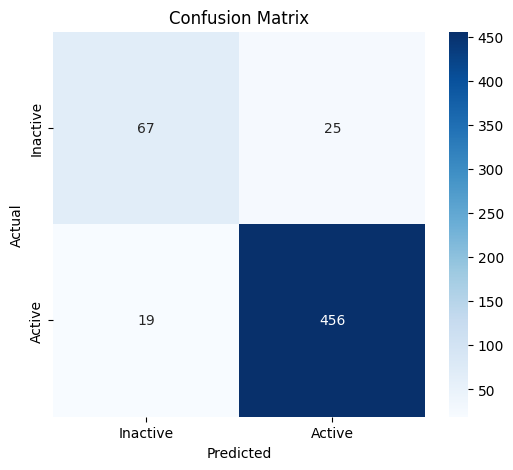

              precision    recall  f1-score   support

           0       0.78      0.73      0.75        92
           1       0.95      0.96      0.95       475

    accuracy                           0.92       567
   macro avg       0.86      0.84      0.85       567
weighted avg       0.92      0.92      0.92       567



In [200]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Robust confusion matrix plot that works for sklearn-like models or the trained PyTorch CNN
import matplotlib.pyplot as plt

# Get predictions and true labels
if hasattr(final_model, "predict") and 'X_test' in globals():
    y_pred_local = final_model.predict(X_test)
    y_true_local = y_test.values if hasattr(y_test, "values") else y_test
elif 'y_pred' in globals() and 'y_true' in globals() and 'y_pred' in globals():
    y_pred_local = y_pred
    y_true_local = y_true
    y_prob_local = y_prob
else:
    # Fall back to using the PyTorch model and test_loader
    final_model.eval()
    preds, trues, probs = [], [], []
    with torch.no_grad():
        for bx, by in test_loader:
            bx = bx.to(device)
            out = final_model(bx)
            pred = torch.argmax(out, dim=1).cpu().numpy()
            prob = torch.softmax(out, dim=1)[:, 1]
            preds.append(pred)
            trues.append(by.numpy())
            probs.append(prob)
    y_pred_local = np.concatenate(preds)
    y_true_local = np.concatenate(trues)
    y_prob_local = np.concatenate(probs)
# Plot
accuracy = accuracy_score(y_true_local, y_pred_local)
balanced_acc = balanced_accuracy_score(y_true_local, y_pred_local)
precision = precision_score(y_true_local, y_pred_local)
recall = recall_score(y_true_local, y_pred_local)  # This is also Sensitivity
f1 = f1_score(y_true_local, y_pred_local)
roc_auc = roc_auc_score(y_true_local, y_prob_local)
mcc = matthews_corrcoef(y_true_local, y_pred_local)
auprc = average_precision_score(y_true_local, y_prob_local)  # Area Under Precision-Recall Curve

# For Specificity: Derive from confusion matrix
cm = confusion_matrix(y_true_local, y_pred_local)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
sensitivity = recall  # Same as recall

# Step 3: Print or store results (e.g., to fill your table)
print(f"Accuracy: {accuracy:.4f}")
print(f"Balanced Acc.: {balanced_acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"AUPRC: {auprc:.4f}")
cm = confusion_matrix(y_true_local, y_pred_local)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Inactive','Active'], yticklabels=['Inactive','Active'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Print classification report
print(classification_report(y_true_local, y_pred_local))

##### 2d

In [201]:
# # Run optimization
# print("Starting CNN hyperparameter optimization...")
# print("="*60)

# # Choose which objective to use
# study = optuna.create_study(
#     direction="minimize",
#     study_name="cnn_optimization",
#     sampler=optuna.samplers.TPESampler(seed=42),
#     pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10)
# )

# # Optimize (use objective_1d for tabular data, objective_2d for images)
# study.optimize(objective_2d, n_trials=50, show_progress_bar=True)

# # Print results
# print("\n" + "="*60)
# print("OPTIMIZATION RESULTS")
# print("="*60)
# print(f"Best trial: {study.best_trial.number}")
# print(f"Best AUC: {1 - study.best_value:.4f}")
# print(f"\nBest hyperparameters:")
# for key, value in study.best_params.items():
#     print(f"  {key}: {value}")

# # Train final model with best parameters
# print("\n" + "="*60)
# print("TRAINING FINAL MODEL")
# print("="*60)

# best_params = study.best_params

# # Recreate best trial for model architecture
# best_trial = study.best_trial

# # Prepare data
# X_train_tensor = torch.FloatTensor(X_train.values if hasattr(X_train, 'values') else X_train)
# y_train_tensor = torch.LongTensor(y_train.values if hasattr(y_train, 'values') else y_train)
# X_test_tensor = torch.FloatTensor(X_test.values if hasattr(X_test, 'values') else X_test)
# y_test_tensor = torch.LongTensor(y_test.values if hasattr(y_test, 'values') else y_test)

# train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
# test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# batch_size = best_params['batch_size']
# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# # Create final model
# input_size = X_train_tensor.shape[1]
# final_model = CNN1D(input_size, best_trial).to(device)

# # Train final model
# criterion = nn.CrossEntropyLoss(weight=class_weights if best_params['use_class_weights'] else None)

# if best_params['optimizer'] == "Adam":
#     optimizer = optim.Adam(final_model.parameters(), lr=best_params['learning_rate'], 
#                           weight_decay=best_params['weight_decay'])
# elif best_params['optimizer'] == "AdamW":
#     optimizer = optim.AdamW(final_model.parameters(), lr=best_params['learning_rate'], 
#                            weight_decay=best_params['weight_decay'])
# else:
#     optimizer = optim.SGD(final_model.parameters(), lr=best_params['learning_rate'], 
#                          momentum=best_params.get('momentum', 0.9), 
#                          weight_decay=best_params['weight_decay'])

# for epoch in range(best_params['n_epochs']):
#     train_loss = train_epoch(final_model, train_loader, criterion, optimizer, device)
#     if (epoch + 1) % 10 == 0:
#         print(f"Epoch {epoch+1}/{best_params['n_epochs']}, Loss: {train_loss:.4f}")

# # Final evaluation
# y_true, y_pred, y_prob = evaluate(final_model, test_loader, device)

# print(f"\nFinal Model Performance:")
# print(f"  Accuracy: {accuracy_score(y_true, y_pred):.4f}")
# print(f"  ROC-AUC: {roc_auc_score(y_true, y_prob):.4f}")
# print(f"  F1 Score: {f1_score(y_true, y_pred):.4f}")

# from sklearn.metrics import classification_report, confusion_matrix
# print(f"\nConfusion Matrix:")
# print(confusion_matrix(y_true, y_pred))
# print(f"\nClassification Report:")
# print(classification_report(y_true, y_pred))

# # Save model
# torch.save(final_model.state_dict(), 'best_cnn_model_2d.pth')
# print("\nModel saved as 'best_cnn_model_2d.pth'")

In [202]:
# from sklearn.metrics import confusion_matrix, classification_report
# import seaborn as sns

# # Robust confusion matrix plot that works for sklearn-like models or the trained PyTorch CNN
# import matplotlib.pyplot as plt

# # Get predictions and true labels
# if hasattr(final_model, "predict") and 'X_test' in globals():
#     y_pred_local = final_model.predict(X_test)
#     y_true_local = y_test.values if hasattr(y_test, "values") else y_test
# elif 'y_pred' in globals() and 'y_true' in globals() and 'y_pred' in globals():
#     y_pred_local = y_pred
#     y_true_local = y_true
#     y_prob_local = y_prob
# else:
#     # Fall back to using the PyTorch model and test_loader
#     final_model.eval()
#     preds, trues, probs = [], [], []
#     with torch.no_grad():
#         for bx, by in test_loader:
#             bx = bx.to(device)
#             out = final_model(bx)
#             pred = torch.argmax(out, dim=1).cpu().numpy()
#             prob = torch.softmax(out, dim=1)[:, 1]
#             preds.append(pred)
#             trues.append(by.numpy())
#             probs.append(prob)
#     y_pred_local = np.concatenate(preds)
#     y_true_local = np.concatenate(trues)
#     y_prob_local = np.concatenate(probs)
# # Plot
# accuracy = accuracy_score(y_true_local, y_pred_local)
# balanced_acc = balanced_accuracy_score(y_true_local, y_pred_local)
# precision = precision_score(y_true_local, y_pred_local)
# recall = recall_score(y_true_local, y_pred_local)  # This is also Sensitivity
# f1 = f1_score(y_true_local, y_pred_local)
# roc_auc = roc_auc_score(y_true_local, y_prob_local)
# mcc = matthews_corrcoef(y_true_local, y_pred_local)
# auprc = average_precision_score(y_true_local, y_prob_local)  # Area Under Precision-Recall Curve

# # For Specificity: Derive from confusion matrix
# cm = confusion_matrix(y_true_local, y_pred_local)
# tn, fp, fn, tp = cm.ravel()
# specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
# sensitivity = recall  # Same as recall

# # Step 3: Print or store results (e.g., to fill your table)
# print(f"Accuracy: {accuracy:.4f}")
# print(f"Balanced Acc.: {balanced_acc:.4f}")
# print(f"Precision: {precision:.4f}")
# print(f"Recall: {recall:.4f}")
# print(f"F1 Score: {f1:.4f}")
# print(f"ROC-AUC: {roc_auc:.4f}")
# print(f"MCC: {mcc:.4f}")
# print(f"Specificity: {specificity:.4f}")
# print(f"Sensitivity: {sensitivity:.4f}")
# print(f"AUPRC: {auprc:.4f}")
# cm = confusion_matrix(y_true_local, y_pred_local)
# plt.figure(figsize=(6,5))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Inactive','Active'], yticklabels=['Inactive','Active'])
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.title('Confusion Matrix')
# plt.show()

# # Print classification report
# print(classification_report(y_true_local, y_pred_local))

#### SVN

In [203]:
import optuna
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# ============================================================================
# SVM (Support Vector Machine) Optimization
# ============================================================================

print("="*70)
print("SVM HYPERPARAMETER OPTIMIZATION")
print("="*70)



# Calculate class weights for imbalance
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"Class imbalance ratio: {scale_pos_weight:.2f}:1\n")

def objective_svm(trial):
    param = {
        # Kernel type
        "kernel": trial.suggest_categorical("kernel", ["linear", "rbf", "poly", "sigmoid"]),
        
        # Regularization parameter
        "C": trial.suggest_float("C", 1e-3, 100, log=True),
        
        # Kernel coefficient (for rbf, poly, sigmoid)
        "gamma": trial.suggest_categorical("gamma", ["scale", "auto"]),
        
        # Degree for polynomial kernel
        "degree": trial.suggest_int("degree", 2, 5) if trial.params.get("kernel") == "poly" else 3,
        
        # Class weight for imbalance
        "class_weight": trial.suggest_categorical("class_weight", ["balanced", None]),
        
        # Probability estimates (needed for ROC-AUC)
        "probability": True,
        
        # Tolerance for stopping criterion
        "tol": trial.suggest_float("tol", 1e-5, 1e-2, log=True),
        
        # Maximum iterations
        "max_iter": trial.suggest_int("max_iter", 100, 2000, step=100),
        
        # Shrinking heuristic
        "shrinking": trial.suggest_categorical("shrinking", [True, False])
    }
    
    # Remove degree if not polynomial kernel
    if param["kernel"] != "poly":
        param.pop("degree", None)
    
    model = SVC(**param)
    model.fit(X_train, y_train)
    
    # Predict probabilities for AUC
    preds_proba = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, preds_proba)
    
    return 1.0 - auc  # Optuna minimizes, so invert AUC

# Create and run study
study_svm = optuna.create_study(
    direction="minimize",
    study_name="svm_optimization",
    sampler=optuna.samplers.TPESampler(seed=42)
)

print("Starting SVM optimization...")
study_svm.optimize(objective_svm, n_trials=50, show_progress_bar=True)

print("\n" + "="*70)
print("SVM OPTIMIZATION RESULTS")
print("="*70)
print(f"Best trial: {study_svm.best_trial.number}")
print(f"Best AUC: {1 - study_svm.best_value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study_svm.best_params.items():
    print(f"  {key}: {value}")

# Train final SVM model with best params
print("\n" + "="*70)
print("TRAINING FINAL SVM MODEL")
print("="*70)

best_params_svm = study_svm.best_params.copy()
best_params_svm.update({
    "probability": True,
    "random_state": 42
})

final_model_svm = SVC(**best_params_svm)
final_model_svm.fit(X_train, y_train)

# Evaluate on test set
y_pred_svm = final_model_svm.predict(X_test)
y_pred_proba_svm = final_model_svm.predict_proba(X_test)[:, 1]

print(f"\nFinal SVM Model Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, y_pred_proba_svm):.4f}")

print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

[I 2025-10-25 23:24:45,088] A new study created in memory with name: svm_optimization


SVM HYPERPARAMETER OPTIMIZATION
Class imbalance ratio: 1.00:1

Starting SVM optimization...


Best trial: 0. Best value: 0.415968:   2%|▏         | 1/50 [00:04<04:03,  4.96s/it]

[I 2025-10-25 23:24:50,050] Trial 0 finished with value: 0.41596818837472227 and parameters: {'kernel': 'rbf', 'C': 0.006026889128682512, 'gamma': 'scale', 'class_weight': 'balanced', 'tol': 0.001331121608073689, 'max_iter': 100, 'shrinking': True}. Best is trial 0 with value: 0.41596818837472227.


Best trial: 1. Best value: 0.177284:   4%|▍         | 2/50 [00:42<19:29, 24.36s/it]

...

[I 2025-10-25 23:59:26,879] Trial 47 finished with value: 0.07030914974075075 and parameters: {'kernel': 'linear', 'C': 0.014773259131372618, 'gamma': 'auto', 'class_weight': 'balanced', 'tol': 0.005882132594676583, 'max_iter': 1500, 'shrinking': False}. Best is trial 30 with value: 0.06740477954075863.


Best trial: 30. Best value: 0.0674048:  98%|█████████▊| 49/50 [35:54<00:44, 44.52s/it]

[I 2025-10-26 00:00:39,207] Trial 48 finished with value: 0.11644770184398268 and parameters: {'kernel': 'rbf', 'C': 0.001025738995348344, 'gamma': 'auto', 'class_weight': 'balanced', 'tol': 0.006851972892591894, 'max_iter': 1200, 'shrinking': True}. Best is trial 30 with value: 0.06740477954075863.


Best trial: 30. Best value: 0.0674048: 100%|██████████| 50/50 [36:16<00:00, 43.53s/it]


[I 2025-10-26 00:01:01,696] Trial 49 finished with value: 0.11309500604264944 and parameters: {'kernel': 'linear', 'C': 0.2615014939994641, 'gamma': 'auto', 'class_weight': 'balanced', 'tol': 0.0048607130523076305, 'max_iter': 1100, 'shrinking': False}. Best is trial 30 with value: 0.06740477954075863.

SVM OPTIMIZATION RESULTS
Best trial: 30
Best AUC: 0.9326

Best hyperparameters:
  kernel: linear
  C: 0.004363074399943229
  gamma: scale
  class_weight: balanced
  tol: 0.0041555242768841014
  max_iter: 1200
  shrinking: False

TRAINING FINAL SVM MODEL

Final SVM Model Performance:
  Accuracy: 0.9012
  ROC-AUC: 0.9152

Confusion Matrix:
[[ 63  29]
 [ 27 448]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.68      0.69        92
           1       0.94      0.94      0.94       475

    accuracy                           0.90       567
   macro avg       0.82      0.81      0.82       567
weighted avg       0.90      0.90   

In [204]:
calc_metrics(final_model_svm)

Accuracy: 0.9012
Balanced Acc.: 0.8140
Precision: 0.9392
Recall: 0.9432
F1 Score: 0.9412
ROC-AUC: 0.9152
MCC: 0.6335
Specificity: 0.6848
Sensitivity: 0.9432
AUPRC: 0.9799


In [205]:


calc_loss(final_model_svm)

Log Loss(Test): 0.31586853299250206
Log Loss(Train): 0.14536550775578483
Focal Loss (Test Set): 0.0589


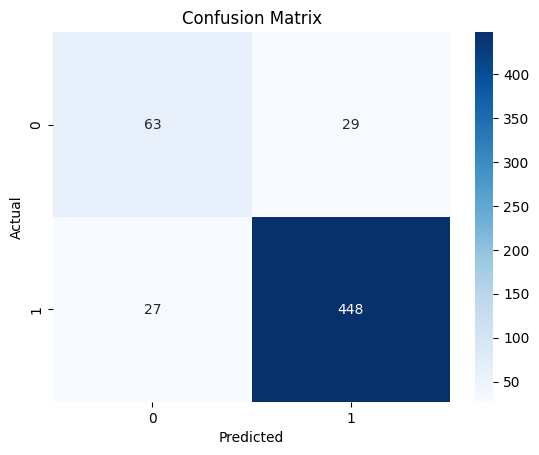

In [206]:

plot_confusion_matrix(final_model_svm)

In [207]:
save_model(final_model_svm, best_params_svm, "svm_bioactivity_model")

Model and metadata saved to saved_model/ml_models/sampling/


In [208]:
# shap_plot(final_model_svm)

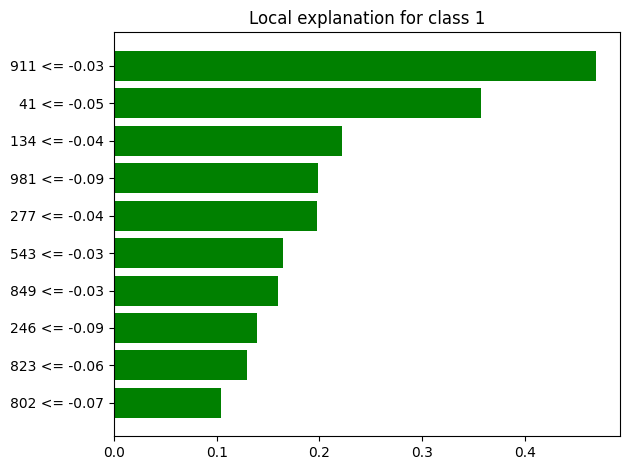


Feature contributions:
[('911 <= -0.03', 0.4692474019522937), ('41 <= -0.05', 0.35783610793011983), ('134 <= -0.04', 0.22157532816064857), ('981 <= -0.09', 0.19897824732095393), ('277 <= -0.04', 0.19792986678158442), ('543 <= -0.03', 0.16445197512312815), ('849 <= -0.03', 0.15984706161824688), ('246 <= -0.09', 0.13904400496556427), ('823 <= -0.06', 0.12999932459328334), ('802 <= -0.07', 0.10428333330234311)]

Explanation as dict:
{1: [(911, 0.4692474019522937), (41, 0.35783610793011983), (134, 0.22157532816064857), (981, 0.19897824732095393), (277, 0.19792986678158442), (543, 0.16445197512312815), (849, 0.15984706161824688), (246, 0.13904400496556427), (823, 0.12999932459328334), (802, 0.10428333330234311)]}


In [209]:
lime_plot(final_model_svm)

#### KNN

In [210]:
import optuna
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# ============================================================================
# KNN (K-Nearest Neighbors) Optimization
# ============================================================================

print("="*70)
print("KNN HYPERPARAMETER OPTIMIZATION")
print("="*70)


# Calculate class weights for imbalance
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"Class imbalance ratio: {scale_pos_weight:.2f}:1\n")

def objective_knn(trial):
    param = {
        # Number of neighbors
        "n_neighbors": trial.suggest_int("n_neighbors", 3, 50, step=2),
        
        # Distance metric
        "metric": trial.suggest_categorical("metric", ["euclidean", "manhattan", "minkowski"]),
        
        # Power parameter for Minkowski distance
        "p": trial.suggest_int("p", 1, 3) if trial.params.get("metric") == "minkowski" else 2,
        
        # Weight function
        "weights": trial.suggest_categorical("weights", ["uniform", "distance"]),
        
        # Algorithm to compute nearest neighbors
        "algorithm": trial.suggest_categorical("algorithm", ["auto", "ball_tree", "kd_tree", "brute"]),
        
        # Leaf size for ball_tree or kd_tree
        "leaf_size": trial.suggest_int("leaf_size", 10, 50, step=5),

        "n_jobs": -1
    }
    
    # Remove p if not minkowski metric
    if param["metric"] != "minkowski":
        param.pop("p", None)
    
    model = KNeighborsClassifier(**param)
    model.fit(X_train, y_train)
    
    # Predict probabilities for AUC (using predict_proba)
    preds_proba = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, preds_proba)
    
    return 1.0 - auc  # Optuna minimizes, so invert AUC

# Create and run study
study_knn = optuna.create_study(
    direction="minimize",
    study_name="knn_optimization",
    sampler=optuna.samplers.TPESampler(seed=42)
)

print("Starting KNN optimization...")
study_knn.optimize(objective_knn, n_trials=50, show_progress_bar=True)

print("\n" + "="*70)
print("KNN OPTIMIZATION RESULTS")
print("="*70)
print(f"Best trial: {study_knn.best_trial.number}")
print(f"Best AUC: {1 - study_knn.best_value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study_knn.best_params.items():
    print(f"  {key}: {value}")

# Train final KNN model with best params
print("\n" + "="*70)
print("TRAINING FINAL KNN MODEL")
print("="*70)

best_params_knn = study_knn.best_params.copy()


final_model_knn = KNeighborsClassifier(**best_params_knn)
final_model_knn.fit(X_train, y_train)

# Evaluate on test set
y_pred_knn = final_model_knn.predict(X_test)
y_pred_proba_knn = final_model_knn.predict_proba(X_test)[:, 1]

print(f"\nFinal KNN Model Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, y_pred_proba_knn):.4f}")

print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

[I 2025-10-26 00:01:47,420] A new study created in memory with name: knn_optimization


KNN HYPERPARAMETER OPTIMIZATION
Class imbalance ratio: 1.00:1

Starting KNN optimization...


Best trial: 0. Best value: 0.127968:   2%|▏         | 1/50 [00:00<00:41,  1.17it/s]

[I 2025-10-26 00:01:48,272] Trial 0 finished with value: 0.12796772055670336 and parameters: {'n_neighbors': 19, 'metric': 'euclidean', 'weights': 'uniform', 'algorithm': 'ball_tree', 'leaf_size': 10}. Best is trial 0 with value: 0.12796772055670336.
[I 2025-10-26 00:01:48,323] Trial 1 finished with value: 0.1374020506023157 and parameters: {'n_neighbors': 49, 'metric': 'euclidean', 'weights': 'distance', 'algorithm': 'brute', 'leaf_size': 15}. Best is trial 0 with value: 0.12796772055670336.


Best trial: 2. Best value: 0.109713:   6%|▌         | 3/50 [00:01<00:24,  1.93it/s]

...

[I 2025-10-26 00:02:23,213] Trial 47 finished with value: 0.13206112822112193 and parameters: {'n_neighbors': 7, 'metric': 'minkowski', 'p': 3, 'weights': 'uniform', 'algorithm': 'ball_tree', 'leaf_size': 50}. Best is trial 10 with value: 0.09239405871116135.


Best trial: 10. Best value: 0.0923941:  98%|█████████▊| 49/50 [00:36<00:00,  1.07it/s]

[I 2025-10-26 00:02:23,457] Trial 48 finished with value: 0.10059062024872323 and parameters: {'n_neighbors': 11, 'metric': 'manhattan', 'weights': 'distance', 'algorithm': 'brute', 'leaf_size': 45}. Best is trial 10 with value: 0.09239405871116135.


Best trial: 10. Best value: 0.0923941: 100%|██████████| 50/50 [00:36<00:00,  1.36it/s]


[I 2025-10-26 00:02:24,191] Trial 49 finished with value: 0.09239405871116135 and parameters: {'n_neighbors': 3, 'metric': 'manhattan', 'weights': 'distance', 'algorithm': 'ball_tree', 'leaf_size': 40}. Best is trial 10 with value: 0.09239405871116135.

KNN OPTIMIZATION RESULTS
Best trial: 10
Best AUC: 0.9076

Best hyperparameters:
  n_neighbors: 3
  metric: manhattan
  weights: distance
  algorithm: ball_tree
  leaf_size: 50

TRAINING FINAL KNN MODEL

Final KNN Model Performance:
  Accuracy: 0.9312
  ROC-AUC: 0.8947

Confusion Matrix:
[[ 72  20]
 [ 19 456]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.78      0.79        92
           1       0.96      0.96      0.96       475

    accuracy                           0.93       567
   macro avg       0.87      0.87      0.87       567
weighted avg       0.93      0.93      0.93       567



In [211]:
calc_metrics(final_model_knn)

Accuracy: 0.9312
Balanced Acc.: 0.8713
Precision: 0.9580
Recall: 0.9600
F1 Score: 0.9590
ROC-AUC: 0.8947
MCC: 0.7459
Specificity: 0.7826
Sensitivity: 0.9600
AUPRC: 0.9625


In [212]:
calc_loss(final_model_knn)

Log Loss(Test): 1.6447534019170849
Log Loss(Train): 0.007924776973875747
Focal Loss (Test Set): 0.2068


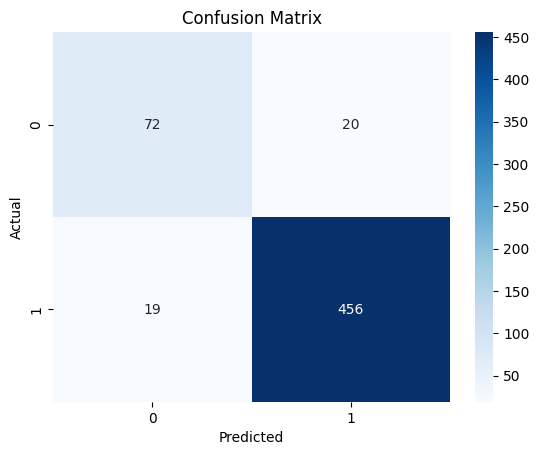

In [213]:
plot_confusion_matrix(final_model_knn)

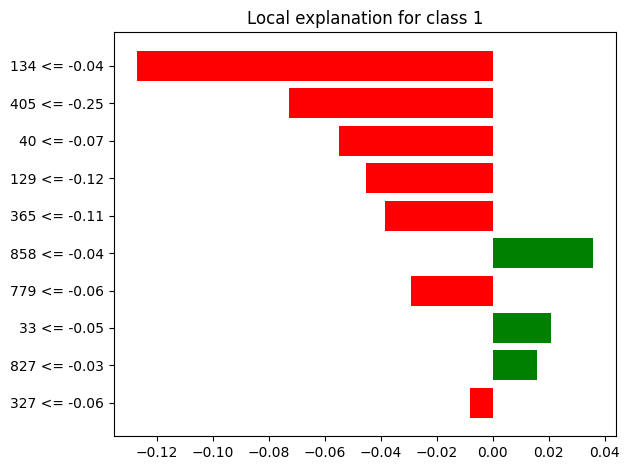


Feature contributions:
[('134 <= -0.04', -0.1271461821235179), ('405 <= -0.25', -0.07285580305865978), ('40 <= -0.07', -0.05493741902487718), ('129 <= -0.12', -0.04508051261536354), ('365 <= -0.11', -0.038397290273091945), ('858 <= -0.04', 0.035964603488864245), ('779 <= -0.06', -0.029032733281358535), ('33 <= -0.05', 0.02077505569217578), ('827 <= -0.03', 0.015965454594733922), ('327 <= -0.06', -0.008029983762406535)]

Explanation as dict:
{1: [(134, -0.1271461821235179), (405, -0.07285580305865978), (40, -0.05493741902487718), (129, -0.04508051261536354), (365, -0.038397290273091945), (858, 0.035964603488864245), (779, -0.029032733281358535), (33, 0.02077505569217578), (827, 0.015965454594733922), (327, -0.008029983762406535)]}


In [214]:
lime_plot(final_model_knn)

In [215]:
save_model(final_model_knn, best_params_knn, "knn_bioactivity_model")

Model and metadata saved to saved_model/ml_models/sampling/


#### Ensembles

In [216]:
import optuna
from sklearn.ensemble import (
    VotingClassifier, 
    StackingClassifier, 
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, f1_score
from sklearn.preprocessing import StandardScaler
import numpy as np



# Calculate class weights
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"Class imbalance ratio: {scale_pos_weight:.2f}:1\n")


# ============================================================================
# 1. VOTING CLASSIFIER (Soft Voting)
# ============================================================================

print("="*70)
print("VOTING CLASSIFIER OPTIMIZATION")
print("="*70)

def objective_voting(trial):
    """
    Voting Classifier with multiple base estimators

    NOTE: to avoid multiprocessing / pickling issues (BrokenProcessPool),
    force single-threaded / no-process parallelism for estimators and the
    VotingClassifier (n_jobs=1). Also enable probability=True for SVC so
    soft voting can use predict_proba.
    """
    
    # Define base estimators with their hyperparameters
    
    # XGBoost
    # xgb_params = {
    #     'n_estimators': trial.suggest_int('xgb_n_estimators', 50, 300),
    #     'max_depth': trial.suggest_int('xgb_max_depth', 3, 10),
    #     'learning_rate': trial.suggest_float('xgb_learning_rate', 0.01, 0.3, log=True),
    #     'scale_pos_weight': scale_pos_weight,
    #     'random_state': 42,
    #     'eval_metric': 'auc',
    #     'n_jobs': 1
    # }
    
    # # LightGBM
    # lgbm_params = {
    #     'n_estimators': trial.suggest_int('lgbm_n_estimators', 50, 300),
    #     'max_depth': trial.suggest_int('lgbm_max_depth', 3, 10),
    #     'learning_rate': trial.suggest_float('lgbm_learning_rate', 0.01, 0.3, log=True),
    #     'scale_pos_weight': scale_pos_weight,
    #     'random_state': 42,
    #     'verbosity': -1,
    #     'n_jobs': 1
    # }
    
    # # Random Forest (via sklearn)
    # from sklearn.ensemble import RandomForestClassifier
    # rf_params = {
    #     'n_estimators': trial.suggest_int('rf_n_estimators', 50, 300),
    #     'max_depth': trial.suggest_int('rf_max_depth', 3, 20),
    #     'class_weight': 'balanced',
    #     'random_state': 42,
    #     'n_jobs': 1
    # }

    # # Support Vector (enable probability for soft voting)
    # sf_params={
    #     'kernel': trial.suggest_categorical('svm_kernel', ['linear', 'rbf', 'poly', 'sigmoid']),
    #     'C': trial.suggest_float('svm_C', 0.01, 10, log=True),
    #     'gamma': trial.suggest_categorical('svm_gamma', ['scale', 'auto']),
    #     'class_weight': 'balanced',
    #     'probability': True,
    #     'random_state': 42
    # }

    
    # # Logistic Regression
    # lr_params = {
    #     'C': trial.suggest_float('lr_C', 0.01, 10, log=True),
    #     'class_weight': 'balanced',
    #     'random_state': 42,
    #     'max_iter': 1000,
    #     'n_jobs': 1
    # }
    
    # Create base estimators
    estimators = [
        ('xgb', final_model_xgb),
        ('lgbm', final_model_lgbm),
        ('rf', final_model_rf),
        ('cat', final_model_cat),
        ('sf', final_model_svm),
        ('ext', final_model_et)
    ]
    
    # Voting type
    voting = trial.suggest_categorical('voting', ['soft', 'hard'])
    
    # Weights for each estimator (if soft voting)
    if voting == 'soft':
        weights = [
            trial.suggest_float(f'weight_{name}', 0.5, 2.0)
            for name in ['xgb', 'lgbm', 'rf', 'cat', 'sf', 'ext']
        ]
    else:
        weights = None
    
    # Create voting classifier
    # Set n_jobs=1 to avoid nested multiprocessing / pickling issues
    voting_model = VotingClassifier(
        estimators=estimators,
        voting=voting,
        weights=weights,
        n_jobs=1
    )
    
    voting_model.fit(X_train, y_train)
    
    if voting == 'soft':
        preds_proba = voting_model.predict_proba(X_val)[:, 1]
    else:
        # For hard voting, use predicted labels and return 1 - accuracy (same as before)
        preds = voting_model.predict(X_val)
        auc = roc_auc_score(y_val, preds)
        return 1.0 - auc
    
    auc = roc_auc_score(y_val, preds_proba)
    return 1.0 - auc

study_voting = optuna.create_study(
    direction="minimize",
    study_name="voting_optimization",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner()
)

print("Starting Voting Classifier optimization...")
study_voting.optimize(objective_voting, n_trials=50, show_progress_bar=True)

print("\n" + "="*70)
print("VOTING CLASSIFIER RESULTS")
print("="*70)
print(f"Best AUC: {1 - study_voting.best_value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study_voting.best_params.items():
    print(f"  {key}: {value}")


[I 2025-10-26 00:04:12,166] A new study created in memory with name: voting_optimization


Class imbalance ratio: 1.00:1

VOTING CLASSIFIER OPTIMIZATION
Starting Voting Classifier optimization...


Best trial: 0. Best value: 0.138211:   2%|▏         | 1/50 [02:41<2:12:02, 161.69s/it]

[I 2025-10-26 00:06:53,857] Trial 0 finished with value: 0.13821098592647463 and parameters: {'voting': 'hard'}. Best is trial 0 with value: 0.13821098592647463.


Best trial: 1. Best value: 0.046236:   4%|▍         | 2/50 [05:22<2:09:06, 161.39s/it]

...

Best trial: 3. Best value: 0.045086:  10%|█         | 5/50 [14:02<2:07:57, 170.60s/it]

[I 2025-10-26 00:18:14,380] Trial 4 finished with value: 0.04584616584148771 and parameters: {'voting': 'soft', 'weight_xgb': 0.9382169728028272, 'weight_lgbm': 1.0495427649405376, 'weight_rf': 1.1841049763255538, 'weight_cat': 1.6777639420895203, 'weight_sf': 0.7995106732375397, 'weight_ext': 1.2713516576204174}. Best is trial 3 with value: 0.0450859615609529.


Best trial: 3. Best value: 0.045086:  10%|█         | 5/50 [15:36<2:20:24, 187.20s/it]


[W 2025-10-26 00:19:48,184] Trial 5 failed with parameters: {'voting': 'soft', 'weight_xgb': 1.4113172778521577, 'weight_lgbm': 0.7557861855309373, 'weight_rf': 0.5975773894779193, 'weight_cat': 1.92332830588, 'weight_sf': 1.948448049611839, 'weight_ext': 1.7125960221746916} because of the following error: KeyboardInterrupt('').
Traceback (most recent call last):
  File "e:\ML\BioActivity\.venv\Lib\site-packages\optuna\study\_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\era\AppData\Local\Temp\ipykernel_39208\705430170.py", line 132, in objective_voting
    voting_model.fit(X_train, y_train)
  File "e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\ensemble\_voting.py", line 405, in fit
    return super().fit(X, transformed

KeyboardInterrupt: 

In [ ]:
import optuna
from optuna.samplers import TPESampler
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score
import os

# SOLUTION 1: Reduce parallelization (Recommended - Simplest)
# ============================================================================

def objective_stacking_v1(trial):
    """
    Stacking Classifier - SOLUTION 1: Use n_jobs=1 or n_jobs=2
    This is the simplest fix and often sufficient.
    """
    
    # Base estimators (Level 0)
    xgb_params = {
        'n_estimators': trial.suggest_int('xgb_n_estimators', 50, 200),
        'max_depth': trial.suggest_int('xgb_max_depth', 3, 8),
        'learning_rate': trial.suggest_float('xgb_learning_rate', 0.01, 0.2, log=True),
        'scale_pos_weight': scale_pos_weight,
        'random_state': 42
    }
    
    lgbm_params = {
        'n_estimators': trial.suggest_int('lgbm_n_estimators', 50, 200),
        'max_depth': trial.suggest_int('lgbm_max_depth', 3, 8),
        'learning_rate': trial.suggest_float('lgbm_learning_rate', 0.01, 0.2, log=True),
        'scale_pos_weight': scale_pos_weight,
        'random_state': 42,
        'verbosity': -1
    }
    
    catboost_params = {
        'iterations': trial.suggest_int('cat_iterations', 50, 200),
        'depth': trial.suggest_int('cat_depth', 3, 8),
        'learning_rate': trial.suggest_float('cat_learning_rate', 0.01, 0.2, log=True),
        'scale_pos_weight': scale_pos_weight,
        'verbose': False,
        'random_state': 42
    }

    sf_params = {
        'kernel': trial.suggest_categorical('svm_kernel', ['linear', 'rbf', 'poly', 'sigmoid']),
        'C': trial.suggest_float('svm_C', 0.01, 10, log=True),
        'gamma': trial.suggest_categorical('svm_gamma', ['scale', 'auto']),
        'class_weight': 'balanced',
        'probability': True,
        'random_state': 42
    }

    rf_params = {
        'n_estimators': trial.suggest_int('rf_n_estimators', 50, 200),
        'max_depth': trial.suggest_int('rf_max_depth', 3, 15),
        'class_weight': 'balanced',
        'random_state': 42,
        'n_jobs': 1  # Restrict individual estimators too
    }
    
    base_estimators = [
        ('xgb', XGBClassifier(**xgb_params)),
        ('lgbm', LGBMClassifier(**lgbm_params)),
        ('catboost', CatBoostClassifier(**catboost_params)),
        ('rf', RandomForestClassifier(**rf_params)),
        ('sf', SVC(**sf_params))
    ]
    
    # Meta-learner (Level 1)
    meta_learner_type = trial.suggest_categorical('meta_learner', ['lr', 'xgb', 'lgbm'])
    
    if meta_learner_type == 'lr':
        meta_learner = LogisticRegression(
            C=trial.suggest_float('meta_C', 0.01, 10, log=True),
            class_weight='balanced',
            random_state=42,
            max_iter=1000
        )
    elif meta_learner_type == 'xgb':
        meta_learner = XGBClassifier(
            n_estimators=trial.suggest_int('meta_n_estimators', 50, 200),
            max_depth=trial.suggest_int('meta_max_depth', 2, 6),
            learning_rate=trial.suggest_float('meta_learning_rate', 0.01, 0.2, log=True),
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            n_jobs=1
        )
    else:  # lgbm
        meta_learner = LGBMClassifier(
            n_estimators=trial.suggest_int('meta_n_estimators', 50, 200),
            max_depth=trial.suggest_int('meta_max_depth', 2, 6),
            learning_rate=trial.suggest_float('meta_learning_rate', 0.01, 0.2, log=True),
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            verbosity=-1,
            n_jobs=1
        )
    
    cv = trial.suggest_int('cv', 3, 5)
    
    # KEY FIX: Use n_jobs=1 instead of n_jobs=-1
    model = StackingClassifier(
        estimators=base_estimators,
        final_estimator=meta_learner,
        cv=cv,
        n_jobs=1,  # CHANGED FROM -1
        passthrough=trial.suggest_categorical('passthrough', [True, False])
    )
    
    try:
        model.fit(X_train, y_train)
        preds_proba = model.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, preds_proba)
        return 1.0 - auc
    except Exception as e:
        print(f"Trial failed with error: {e}")
        return 1.0  # Return worst score


# SOLUTION 2: Use ThreadPoolExecutor instead of ProcessPoolExecutor
# ============================================================================

def objective_stacking_v2(trial):
    """
    SOLUTION 2: Add backend='threading' to StackingClassifier
    This avoids pickling issues by using threading instead of multiprocessing.
    Note: Only works with sklearn >= 1.3
    """
    # ... (same parameter setup as v1) ...
    
    model = StackingClassifier(
        estimators=base_estimators,
        final_estimator=meta_learner,
        cv=cv,
        n_jobs=-1,
        backend='threading',  # Use threading instead of processes
        passthrough=trial.suggest_categorical('passthrough', [True, False])
    )
    
    # ... rest of code ...


# SOLUTION 3: Set Optuna to use ThreadPoolExecutor
# ============================================================================

def run_optimization_with_threading():
    """
    SOLUTION 3: Configure Optuna to use threading
    """
    # Set environment variable
    os.environ['OPTUNA_DISABLE_FORK'] = '1'
    
    study = optuna.create_study(
        direction="minimize",
        study_name="stacking_optimization",
        sampler=TPESampler(seed=42)
    )
    
    # Use executor with threading
    study.optimize(
        objective_stacking_v1,
        n_trials=25,
        show_progress_bar=True,
        n_jobs=1  # Let Optuna handle trials sequentially
    )
    
    return study


# ============================================================================
# RECOMMENDED: Use this optimized version
# ============================================================================

print("\n\n" + "="*70)
print("STACKING CLASSIFIER OPTIMIZATION (FIXED)")
print("="*70)

# Set environment variable before creating study
os.environ['OPTUNA_DISABLE_FORK'] = '1'

study_stacking = optuna.create_study(
    direction="minimize",
    study_name="stacking_optimization",
    sampler=optuna.samplers.TPESampler(seed=42)
)

print("Starting Stacking Classifier optimization...")
study_stacking.optimize(objective_stacking_v1, n_trials=25, show_progress_bar=True)

print("\n" + "="*70)
print("STACKING CLASSIFIER RESULTS")
print("="*70)
print(f"Best AUC: {1 - study_stacking.best_value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study_stacking.best_params.items():
    print(f"  {key}: {value}")

[I 2025-10-25 00:50:05,288] A new study created in memory with name: stacking_optimization




STACKING CLASSIFIER OPTIMIZATION (FIXED)
Starting Stacking Classifier optimization...


Best trial: 0. Best value: 0.0526776:   4%|▍         | 1/25 [02:57<1:11:10, 177.94s/it]

[I 2025-10-25 00:53:03,227] Trial 0 finished with value: 0.05267763019186167 and parameters: {'xgb_n_estimators': 106, 'xgb_max_depth': 8, 'xgb_learning_rate': 0.08960785365368121, 'lgbm_n_estimators': 140, 'lgbm_max_depth': 3, 'lgbm_learning_rate': 0.015957084694148364, 'cat_iterations': 58, 'cat_depth': 8, 'cat_learning_rate': 0.06054365855469246, 'svm_kernel': 'poly', 'svm_C': 0.04335281794951567, 'svm_gamma': 'auto', 'rf_n_estimators': 95, 'rf_max_depth': 9, 'meta_learner': 'lgbm', 'meta_n_estimators': 71, 'meta_max_depth': 3, 'meta_learning_rate': 0.029967309097101588, 'cv': 4, 'passthrough': True}. Best is trial 0 with value: 0.05267763019186167.


Best trial: 0. Best value: 0.0526776:   8%|▊         | 2/25 [05:28<1:02:08, 162.09s/it]

...

[I 2025-10-25 01:41:01,148] Trial 22 finished with value: 0.05462787265443814 and parameters: {'xgb_n_estimators': 116, 'xgb_max_depth': 3, 'xgb_learning_rate': 0.024922927805490446, 'lgbm_n_estimators': 132, 'lgbm_max_depth': 5, 'lgbm_learning_rate': 0.1986268331500438, 'cat_iterations': 121, 'cat_depth': 6, 'cat_learning_rate': 0.15716963890918279, 'svm_kernel': 'sigmoid', 'svm_C': 8.821901196082111, 'svm_gamma': 'scale', 'rf_n_estimators': 184, 'rf_max_depth': 4, 'meta_learner': 'xgb', 'meta_n_estimators': 70, 'meta_max_depth': 5, 'meta_learning_rate': 0.09734538319917638, 'cv': 3, 'passthrough': True}. Best is trial 21 with value: 0.044592030360531276.


Best trial: 21. Best value: 0.044592:  96%|█████████▌| 24/25 [51:43<01:16, 76.09s/it]

[I 2025-10-25 01:41:48,831] Trial 23 finished with value: 0.05039004849251527 and parameters: {'xgb_n_estimators': 137, 'xgb_max_depth': 4, 'xgb_learning_rate': 0.04594559951711415, 'lgbm_n_estimators': 96, 'lgbm_max_depth': 4, 'lgbm_learning_rate': 0.05892479154479186, 'cat_iterations': 81, 'cat_depth': 8, 'cat_learning_rate': 0.151060847260495, 'svm_kernel': 'linear', 'svm_C': 0.20927244238059875, 'svm_gamma': 'scale', 'rf_n_estimators': 175, 'rf_max_depth': 6, 'meta_learner': 'xgb', 'meta_n_estimators': 87, 'meta_max_depth': 4, 'meta_learning_rate': 0.05258188828514663, 'cv': 3, 'passthrough': True}. Best is trial 21 with value: 0.044592030360531276.


Best trial: 21. Best value: 0.044592: 100%|██████████| 25/25 [53:14<00:00, 127.77s/it]

[I 2025-10-25 01:43:19,567] Trial 24 finished with value: 0.06106894370651483 and parameters: {'xgb_n_estimators': 83, 'xgb_max_depth': 5, 'xgb_learning_rate': 0.07489302450950064, 'lgbm_n_estimators': 114, 'lgbm_max_depth': 5, 'lgbm_learning_rate': 0.036097853805456284, 'cat_iterations': 93, 'cat_depth': 3, 'cat_learning_rate': 0.10234663117548867, 'svm_kernel': 'sigmoid', 'svm_C': 0.17275212289606845, 'svm_gamma': 'scale', 'rf_n_estimators': 143, 'rf_max_depth': 4, 'meta_learner': 'lgbm', 'meta_n_estimators': 65, 'meta_max_depth': 3, 'meta_learning_rate': 0.14884300635789627, 'cv': 3, 'passthrough': True}. Best is trial 21 with value: 0.044592030360531276.

STACKING CLASSIFIER RESULTS
Best AUC: 0.9554

Best hyperparameters:
  xgb_n_estimators: 112
  xgb_max_depth: 4
  xgb_learning_rate: 0.049015508208324725
  lgbm_n_estimators: 132
  lgbm_max_depth: 5
  lgbm_learning_rate: 0.03841704330843127
  cat_iterations: 75
  cat_depth: 7
  cat_learning_rate: 0.14516742670515045
  svm_kernel: l

In [ ]:
# # ============================================================================
# # 3. BAGGING CLASSIFIER
# # ============================================================================

# print("\n\n" + "="*70)
# print("BAGGING CLASSIFIER OPTIMIZATION")
# print("="*70)

# def objective_bagging(trial):
#     """
#     Bagging Classifier with optimized base estimator
#     """
    
#     # Base estimator choice
#     base_estimator_type = trial.suggest_categorical('base_estimator', ['dt', 'svm', 'knn'])
    
#     if base_estimator_type == 'dt':
#         base_estimator = DecisionTreeClassifier(
#             max_depth=trial.suggest_int('dt_max_depth', 3, 20),
#             min_samples_split=trial.suggest_int('dt_min_samples_split', 2, 10),
#             min_samples_leaf=trial.suggest_int('dt_min_samples_leaf', 1, 5),
#             class_weight='balanced',
#             random_state=42
#         )
#     elif base_estimator_type == 'svm':
#         base_estimator = SVC(
#             C=trial.suggest_float('svm_C', 0.1, 10, log=True),
#             kernel=trial.suggest_categorical('svm_kernel', ['rbf', 'linear']),
#             class_weight='balanced',
#             probability=True,
#             random_state=42
#         )
#     else:  # knn
#         base_estimator = KNeighborsClassifier(
#             n_neighbors=trial.suggest_int('knn_n_neighbors', 3, 20),
#             weights=trial.suggest_categorical('knn_weights', ['uniform', 'distance']),
#             metric='minkowski'
#         )
    
#     # Bagging parameters
#     param = {
#         'estimator': base_estimator,
#         'n_estimators': trial.suggest_int('n_estimators', 10, 100),
#         'max_samples': trial.suggest_float('max_samples', 0.5, 1.0),
#         'max_features': trial.suggest_float('max_features', 0.5, 1.0),
#         'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
#         'bootstrap_features': trial.suggest_categorical('bootstrap_features', [True, False]),
#         'random_state': 42,
#         'n_jobs': -1
#     }
    
#     model = BaggingClassifier(**param)
    
#     # Use scaled data for SVM and KNN
#     if base_estimator_type in ['svm', 'knn']:
#         model.fit(X_train, y_train)
#         preds_proba = model.predict_proba(X_val)[:, 1]
#     else:
#         model.fit(X_train, y_train)
#         preds_proba = model.predict_proba(X_val)[:, 1]
    
#     auc = roc_auc_score(y_val, preds_proba)
#     return 1.0 - auc

# study_bagging = optuna.create_study(
#     direction="minimize",
#     study_name="bagging_optimization",
#     sampler=optuna.samplers.TPESampler(seed=42)
# )

# print("Starting Bagging Classifier optimization...")
# study_bagging.optimize(objective_bagging, n_trials=30, show_progress_bar=True)

# print("\n" + "="*70)
# print("BAGGING CLASSIFIER RESULTS")
# print("="*70)
# print(f"Best AUC: {1 - study_bagging.best_value:.4f}")
# print(f"\nBest hyperparameters:")
# for key, value in study_bagging.best_params.items():
#     print(f"  {key}: {value}")




In [ ]:
import optuna
from optuna.samplers import TPESampler
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
import os

# ============================================================================
# 3. BAGGING CLASSIFIER (FIXED)
# ============================================================================

print("\n\n" + "="*70)
print("BAGGING CLASSIFIER OPTIMIZATION")
print("="*70)

def objective_bagging(trial):
    """
    Bagging Classifier with optimized base estimator
    FIXED: Changed n_jobs=-1 to n_jobs=1
    """
    
    # Base estimator choice
    base_estimator_type = trial.suggest_categorical('base_estimator', ['dt', 'svm', 'knn'])
    
    if base_estimator_type == 'dt':
        base_estimator = DecisionTreeClassifier(
            max_depth=trial.suggest_int('dt_max_depth', 3, 20),
            min_samples_split=trial.suggest_int('dt_min_samples_split', 2, 10),
            min_samples_leaf=trial.suggest_int('dt_min_samples_leaf', 1, 5),
            class_weight='balanced',
            random_state=42
        )
    elif base_estimator_type == 'svm':
        base_estimator = SVC(
            C=trial.suggest_float('svm_C', 0.1, 10, log=True),
            kernel=trial.suggest_categorical('svm_kernel', ['rbf', 'linear']),
            class_weight='balanced',
            probability=True,
            random_state=42
        )
    else:  # knn
        base_estimator = KNeighborsClassifier(
            n_neighbors=trial.suggest_int('knn_n_neighbors', 3, 20),
            weights=trial.suggest_categorical('knn_weights', ['uniform', 'distance']),
            metric='minkowski'
        )
    
    # Bagging parameters
    param = {
        'estimator': base_estimator,
        'n_estimators': trial.suggest_int('n_estimators', 10, 100),
        'max_samples': trial.suggest_float('max_samples', 0.5, 1.0),
        'max_features': trial.suggest_float('max_features', 0.5, 1.0),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'bootstrap_features': trial.suggest_categorical('bootstrap_features', [True, False]),
        'random_state': 42,
        'n_jobs': 1  # CHANGED FROM -1 (CRITICAL FIX)
    }
    
    model = BaggingClassifier(**param)
    
    try:
        # Fit the model
        model.fit(X_train, y_train)
        
        # Get predictions
        preds_proba = model.predict_proba(X_val)[:, 1]
        
        # Calculate AUC
        auc = roc_auc_score(y_val, preds_proba)
        
        return 1.0 - auc
    
    except Exception as e:
        print(f"Trial failed with error: {e}")
        return 1.0  # Return worst score on failure


# Set environment variable to prevent forking issues
os.environ['OPTUNA_DISABLE_FORK'] = '1'

# Create study
study_bagging = optuna.create_study(
    direction="minimize",
    study_name="bagging_optimization",
    sampler=optuna.samplers.TPESampler(seed=42)
)

print("Starting Bagging Classifier optimization...")
study_bagging.optimize(objective_bagging, n_trials=30, show_progress_bar=True)

print("\n" + "="*70)
print("BAGGING CLASSIFIER RESULTS")
print("="*70)
print(f"Best AUC: {1 - study_bagging.best_value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study_bagging.best_params.items():
    print(f"  {key}: {value}")

[I 2025-10-25 01:55:02,021] A new study created in memory with name: bagging_optimization




BAGGING CLASSIFIER OPTIMIZATION
Starting Bagging Classifier optimization...


Best trial: 0. Best value: 0.0630824:   3%|▎         | 1/30 [01:51<53:54, 111.52s/it]

[I 2025-10-25 01:56:53,547] Trial 0 finished with value: 0.06308243727598561 and parameters: {'base_estimator': 'svm', 'svm_C': 1.5751320499779735, 'svm_kernel': 'rbf', 'n_estimators': 15, 'max_samples': 0.9330880728874675, 'max_features': 0.8005575058716043, 'bootstrap': True, 'bootstrap_features': True}. Best is trial 0 with value: 0.06308243727598561.


Best trial: 0. Best value: 0.0630824:   7%|▋         | 2/30 [01:53<22:04, 47.29s/it] 

...

[I 2025-10-25 02:18:59,853] Trial 27 finished with value: 0.05604048070841239 and parameters: {'base_estimator': 'dt', 'dt_max_depth': 14, 'dt_min_samples_split': 5, 'dt_min_samples_leaf': 2, 'n_estimators': 75, 'max_samples': 0.8393171914560478, 'max_features': 0.671504675605433, 'bootstrap': False, 'bootstrap_features': True}. Best is trial 24 with value: 0.05110689437065141.


Best trial: 24. Best value: 0.0511069:  97%|█████████▋| 29/30 [57:04<10:14, 614.03s/it]

[I 2025-10-25 02:52:06,874] Trial 28 finished with value: 0.08178368121442126 and parameters: {'base_estimator': 'svm', 'svm_C': 0.18189366309739655, 'svm_kernel': 'rbf', 'n_estimators': 100, 'max_samples': 0.9437216189094652, 'max_features': 0.5962860776761355, 'bootstrap': False, 'bootstrap_features': True}. Best is trial 24 with value: 0.05110689437065141.


Best trial: 24. Best value: 0.0511069: 100%|██████████| 30/30 [57:13<00:00, 114.44s/it]

[I 2025-10-25 02:52:15,365] Trial 29 finished with value: 0.08654859793379732 and parameters: {'base_estimator': 'knn', 'knn_n_neighbors': 19, 'knn_weights': 'distance', 'n_estimators': 57, 'max_samples': 0.9203529413370048, 'max_features': 0.857131129983763, 'bootstrap': True, 'bootstrap_features': True}. Best is trial 24 with value: 0.05110689437065141.

BAGGING CLASSIFIER RESULTS
Best AUC: 0.9489

Best hyperparameters:
  base_estimator: dt
  dt_max_depth: 18
  dt_min_samples_split: 6
  dt_min_samples_leaf: 2
  n_estimators: 84
  max_samples: 0.833651149285474
  max_features: 0.6047934968523393
  bootstrap: False
  bootstrap_features: True


In [ ]:
# ============================================================================
# 5. GRADIENT BOOSTING CLASSIFIER
# ============================================================================

print("\n\n" + "="*70)
print("GRADIENT BOOSTING CLASSIFIER OPTIMIZATION")
print("="*70)

def objective_gradientboosting(trial):
    """
    Gradient Boosting Classifier optimization
    """
    
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'loss': trial.suggest_categorical('loss', ['log_loss', 'exponential']),
        'random_state': 42
    }
    
    model = GradientBoostingClassifier(**param)
    model.fit(X_train, y_train)
    preds_proba = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, preds_proba)
    
    return 1.0 - auc

study_gb = optuna.create_study(
    direction="minimize",
    study_name="gradientboosting_optimization",
    sampler=optuna.samplers.TPESampler(seed=42)
)

print("Starting Gradient Boosting optimization...")
study_gb.optimize(objective_gradientboosting, n_trials=30, show_progress_bar=True)

print("\n" + "="*70)
print("GRADIENT BOOSTING RESULTS")
print("="*70)
print(f"Best AUC: {1 - study_gb.best_value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study_gb.best_params.items():
    print(f"  {key}: {value}")




[I 2025-10-25 02:52:15,383] A new study created in memory with name: gradientboosting_optimization




GRADIENT BOOSTING CLASSIFIER OPTIMIZATION
Starting Gradient Boosting optimization...


Best trial: 0. Best value: 0.0590133:   3%|▎         | 1/30 [00:00<00:24,  1.20it/s]

[I 2025-10-25 02:52:16,200] Trial 0 finished with value: 0.05901328273244777 and parameters: {'n_estimators': 218, 'learning_rate': 0.2536999076681772, 'max_depth': 10, 'min_samples_split': 13, 'min_samples_leaf': 2, 'subsample': 0.5779972601681014, 'max_features': 'log2', 'loss': 'log_loss'}. Best is trial 0 with value: 0.05901328273244777.


Best trial: 0. Best value: 0.0590133:   7%|▋         | 2/30 [00:02<00:36,  1.32s/it]

...

[I 2025-10-25 02:54:26,543] Trial 27 finished with value: 0.07115749525616699 and parameters: {'n_estimators': 235, 'learning_rate': 0.05103394275720652, 'max_depth': 7, 'min_samples_split': 9, 'min_samples_leaf': 5, 'subsample': 0.6614581510218185, 'max_features': 'log2', 'loss': 'log_loss'}. Best is trial 25 with value: 0.04745941387307617.


Best trial: 25. Best value: 0.0474594:  97%|█████████▋| 29/30 [02:35<00:08,  8.06s/it]

[I 2025-10-25 02:54:50,776] Trial 28 finished with value: 0.06468479865064314 and parameters: {'n_estimators': 304, 'learning_rate': 0.022649705240857215, 'max_depth': 6, 'min_samples_split': 8, 'min_samples_leaf': 8, 'subsample': 0.7949698813618642, 'max_features': None, 'loss': 'log_loss'}. Best is trial 25 with value: 0.04745941387307617.


Best trial: 25. Best value: 0.0474594: 100%|██████████| 30/30 [02:36<00:00,  5.22s/it]

[I 2025-10-25 02:54:52,011] Trial 29 finished with value: 0.05576639257853677 and parameters: {'n_estimators': 211, 'learning_rate': 0.0746697172628503, 'max_depth': 10, 'min_samples_split': 13, 'min_samples_leaf': 7, 'subsample': 0.5634668012615414, 'max_features': 'sqrt', 'loss': 'log_loss'}. Best is trial 25 with value: 0.04745941387307617.

GRADIENT BOOSTING RESULTS
Best AUC: 0.9525

Best hyperparameters:
  n_estimators: 304
  learning_rate: 0.07482227022847902
  max_depth: 9
  min_samples_split: 8
  min_samples_leaf: 7
  subsample: 0.6694955276426213
  max_features: sqrt
  loss: log_loss


In [ ]:
# ============================================================================
# FINAL COMPARISON OF ALL ENSEMBLE MODELS
# ============================================================================

print("\n\n" + "="*70)
print("ALL ENSEMBLE MODELS COMPARISON")
print("="*70)

ensemble_results = {
    "Voting": 1 - study_voting.best_value,
    "Stacking": 1 - study_stacking.best_value,
    "Bagging": 1 - study_bagging.best_value,
    #"AdaBoost": 1 - study_adaboost.best_value,
    "Gradient Boosting": 1 - study_gb.best_value
}

print(f"\n{'Model':<25} {'Best AUC':<10}")
print("-" * 35)
for model_name, auc in sorted(ensemble_results.items(), key=lambda x: x[1], reverse=True):
    print(f"{model_name:<25} {auc:.4f}")

best_ensemble = max(ensemble_results.items(), key=lambda x: x[1])
print(f"\n🏆 Best Ensemble Model: {best_ensemble[0]} (AUC: {best_ensemble[1]:.4f})")

print("\n" + "="*70)
print("OPTIMIZATION COMPLETE!")
print("="*70)



ALL ENSEMBLE MODELS COMPARISON

Model                     Best AUC  
-----------------------------------
Stacking                  0.9554
Gradient Boosting         0.9525
Voting                    0.9497
Bagging                   0.9489

🏆 Best Ensemble Model: Stacking (AUC: 0.9554)

OPTIMIZATION COMPLETE!


[10:38:45] DEPRECATION WARNING: please use MorganGenerator
[10:38:45] DEPRECATION WARNING: please use MorganGenerator
[10:38:45] DEPRECATION WARNING: please use MorganGenerator
[10:38:45] DEPRECATION WARNING: please use MorganGenerator
[10:38:45] DEPRECATION WARNING: please use MorganGenerator
[10:38:45] DEPRECATION WARNING: please use MorganGenerator
[10:38:45] DEPRECATION WARNING: please use MorganGenerator
[10:38:45] DEPRECATION WARNING: please use MorganGenerator
[10:38:45] DEPRECATION WARNING: please use MorganGenerator
[10:38:45] DEPRECATION WARNING: please use MorganGenerator
[10:38:45] DEPRECATION WARNING: please use MorganGenerator
[10:38:45] DEPRECATION WARNING: please use MorganGenerator
[10:38:45] DEPRECATION WARNING: please use MorganGenerator
[10:38:45] DEPRECATION WARNING: please use MorganGenerator
[10:38:45] DEPRECATION WARNING: please use MorganGenerator
[10:38:45] DEPRECATION WARNING: please use MorganGenerator
[10:38:45] DEPRECATION WARNING: please use MorganGenerat

Tanimoto Similarity Analysis:
Mean Similarity: 0.187
Median Similarity: 0.171
Min Similarity: 0.000
Max Similarity: 1.000


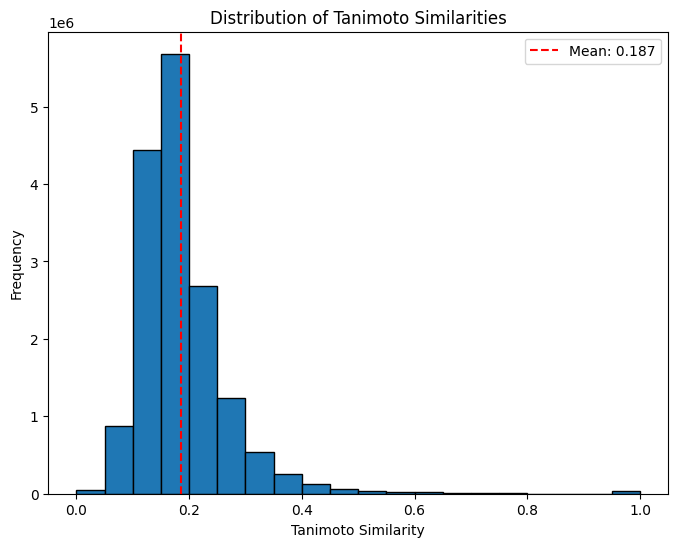


Dataset is relatively homogeneous (mean similarity: 0.187 >= 0.7 or max: 1.000 >= 0.9).
Recommendation: Use 1000 dimensions with radius 2 to avoid overfitting.


In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.DataStructs import FingerprintSimilarity, TanimotoSimilarity
import numpy as np
import matplotlib.pyplot as plt

# Function to generate Morgan fingerprints
def generate_morgan_fp(smiles, radius=2, n_bits=1000):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)

# Example SMILES list (replace with your actual SMILES dataset)
smiles_list = features_df['canonical_smiles'].to_list()
# Generate Morgan fingerprints (using 1000D, radius 2 as a baseline)
fps = [generate_morgan_fp(smile) for smile in smiles_list]
fps = [fp for fp in fps if fp is not None]  # Filter out None values

# Calculate pairwise Tanimoto similarities
n_mols = len(fps)
similarity_matrix = np.zeros((n_mols, n_mols))
for i in range(n_mols):
    for j in range(i, n_mols):  # Only upper triangle to avoid duplicate calculations
        sim = TanimotoSimilarity(fps[i], fps[j])
        similarity_matrix[i, j] = sim
        similarity_matrix[j, i] = sim  # Symmetric matrix

# Extract unique pairwise similarities (excluding diagonal)
similarities = similarity_matrix[np.triu_indices(n_mols, k=1)]

# Statistical summary
mean_similarity = np.mean(similarities)
median_similarity = np.median(similarities)
min_similarity = np.min(similarities)
max_similarity = np.max(similarities)

print("Tanimoto Similarity Analysis:")
print(f"Mean Similarity: {mean_similarity:.3f}")
print(f"Median Similarity: {median_similarity:.3f}")
print(f"Min Similarity: {min_similarity:.3f}")
print(f"Max Similarity: {max_similarity:.3f}")

# Visualize similarity distribution
plt.figure(figsize=(8, 6))
plt.hist(similarities, bins=20, edgecolor='black')
plt.title("Distribution of Tanimoto Similarities")
plt.xlabel("Tanimoto Similarity")
plt.ylabel("Frequency")
plt.axvline(mean_similarity, color='r', linestyle='dashed', label=f'Mean: {mean_similarity:.3f}')
plt.legend()
plt.show()

# Interpretation
diversity_threshold = 0.7  # Common threshold for chemical diversity
if mean_similarity < diversity_threshold and max_similarity < 0.9:
    print(f"\nDataset is diverse (mean similarity: {mean_similarity:.3f} < {diversity_threshold}).")
    print("Recommendation: Use 2048 dimensions with radius 3 for better coverage.")
elif mean_similarity >= diversity_threshold or max_similarity >= 0.9:
    print(f"\nDataset is relatively homogeneous (mean similarity: {mean_similarity:.3f} >= {diversity_threshold} or max: {max_similarity:.3f} >= 0.9).")
    print("Recommendation: Use 1000 dimensions with radius 2 to avoid overfitting.")
else:
    print("\nDataset has moderate diversity. Test both configurations (1000D, r2 and 2048D, r3) to compare performance.")